# Notebook 2 — ECG Signal Preprocessing

## Dissertation: Lightweight ECG Signal Classification Using Machine Learning and Deep Learning Models

### Purpose

This notebook focuses on the preprocessing and preparation of electrocardiogram (ECG) signals obtained from the Dryad physiological monitoring dataset.

The primary objective is to develop a reproducible preprocessing pipeline that prepares raw ECG recordings for subsequent machine-learning and deep-learning analysis. The preprocessing stage includes dataset structure verification, ECG recording inspection, signal quality assessment, handling of missing or invalid observations, noise and baseline-wander treatment, filtering, normalization where appropriate, and segmentation of the ECG signals.

Because the dataset contains participant-level physiological recordings with potentially different numbers of ECG files per participant, the preprocessing workflow is designed to automatically discover and process available recordings rather than assuming a fixed file structure or recording count.

### Dataset

The ECG recordings used in this notebook are obtained from the Dryad dataset:

**24-hour physiological monitoring: Electrocardiogram, interstitial glucose, and ambulatory blood pressure**

DOI: `10.5061/dryad.qjq2bvqpk`

The complete `Per_Participant_Sensor_Data.zip` archive is stored in Google Drive and will be inspected without unnecessarily extracting the entire archive.

### Scope

This notebook concentrates exclusively on ECG signal preprocessing and preparation. Model development and optimisation are outside the scope of this notebook and will be addressed in subsequent stages of the dissertation.

All preprocessing decisions will be based on inspection of the actual recordings and will be documented and justified to support reproducibility and scientific validity.





In [ ]:
# Core libraries for ECG preprocessing and dataset inspection

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
# Path to the complete ECG participant dataset
zip_path = "/content/drive/MyDrive/QMUL_MSc_Dissertation/Per_Participant_Sensor_Data.zip"

# Basic file verification
if os.path.exists(zip_path):
    file_size_gb = os.path.getsize(zip_path) / (1024 ** 3)

    print("Dataset ZIP found successfully.")
    print(f"Path: {zip_path}")
    print(f"Size: {file_size_gb:.2f} GB")
    print(f"Valid ZIP archive: {zipfile.is_zipfile(zip_path)}")
else:
    print("Dataset ZIP was not found at the expected path.")

Dataset ZIP found successfully.
Path: /content/drive/MyDrive/QMUL_MSc_Dissertation/Per_Participant_Sensor_Data.zip
Size: 3.93 GB
Valid ZIP archive: True


In [ ]:
# Inspect the ZIP archive without extracting it

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    all_files = zip_ref.namelist()

print(f"Total files in archive: {len(all_files)}")

print("\nFirst 30 paths in the archive:")
for path in all_files[:30]:
    print(path)

Total files in archive: 585

First 30 paths in the archive:
Per_Participant_Sensor_Data/001/
Per_Participant_Sensor_Data/001/001_ABPM/
Per_Participant_Sensor_Data/001/001_ABPM/001_ABPM.csv
Per_Participant_Sensor_Data/001/001_CGM/
Per_Participant_Sensor_Data/001/001_CGM/001_glucose.csv
Per_Participant_Sensor_Data/001/001_Zephyr/
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_Accel.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_BB.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_Breathing.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_ECG.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_Event_Data.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_RR.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_Summary.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__15_38_43_Accel.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__15_38_43_Accel.dat
P

In [ ]:
# Find all ECG files inside the ZIP archive

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    ecg_files = [
        path for path in zip_ref.namelist()
        if "_ECG." in path
    ]

print(f"Total ECG files found: {len(ecg_files)}")

print("\nFirst 20 ECG files:")
for path in ecg_files[:20]:
    print(path)

Total ECG files found: 60

First 20 ECG files:
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_ECG.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__15_38_43_ECG.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__15_38_43_ECG.dat
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__15_38_43_ECG.hed
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_07__10_42_46_ECG.csv
Per_Participant_Sensor_Data/002/002_Zephyr/2022_06_21__08_03_26_ECG.csv
Per_Participant_Sensor_Data/002/002_Zephyr/2022_06_21__08_43_49_ECG.csv
Per_Participant_Sensor_Data/002/002_Zephyr/2022_06_21__11_53_12_ECG.csv
Per_Participant_Sensor_Data/003/003_Zephyr/2022_08_01__09_38_43_ECG.csv
Per_Participant_Sensor_Data/003/003_Zephyr/2022_08_01__09_59_53_ECG.csv
Per_Participant_Sensor_Data/003/003_Zephyr/2022_08_01__10_06_54_ECG.csv
Per_Participant_Sensor_Data/003/003_Zephyr/2022_08_01__10_08_04_ECG.csv
Per_Participant_Sensor_Data/004/004_Zephyr/2022_08_02__09_15_42_ECG.csv
Per_Participant_S

In [ ]:
# Count ECG files by file extension

extension_counts = {}

for path in ecg_files:
    extension = os.path.splitext(path)[1].lower()
    extension_counts[extension] = extension_counts.get(extension, 0) + 1

print("ECG files by extension:")
for extension, count in sorted(extension_counts.items()):
    print(f"{extension}: {count}")

ECG files by extension:
.csv: 58
.dat: 1
.hed: 1


In [ ]:
# Identify unique ECG recordings from the CSV filenames

ecg_csv_files = [path for path in ecg_files if path.lower().endswith(".csv")]

recordings = []

for path in ecg_csv_files:
    filename = os.path.basename(path)
    parts = filename.split("_")

    # The timestamp is the first six parts after the participant folder
    timestamp = "_".join(parts[:6])

    # Extract participant ID from the folder structure
    participant_id = path.split("/")[2].replace("_Zephyr", "")

    recordings.append({
        "participant": participant_id,
        "timestamp": timestamp,
        "path": path
    })

recordings_df = pd.DataFrame(recordings)

print(f"Unique ECG CSV recordings found: {len(recordings_df)}")
print(f"Participants with ECG recordings: {recordings_df['participant'].nunique()}")

print("\nRecordings per participant:")
print(recordings_df["participant"].value_counts().sort_index())

Unique ECG CSV recordings found: 58
Participants with ECG recordings: 30

Recordings per participant:
participant
001    3
002    3
003    4
004    3
005    4
006    3
007    3
008    4
009    2
010    1
011    2
012    1
013    1
014    1
015    1
016    1
017    1
018    1
019    3
020    4
021    1
022    1
023    1
024    1
025    2
026    2
027    1
028    1
029    1
030    1
Name: count, dtype: int64


## Dataset Access and Structure Verification

The Google Drive connection and the `Per_Participant_Sensor_Data.zip` archive were successfully verified. The archive was confirmed to be a valid ZIP file and was inspected without extracting the complete dataset.

The archive contains participant-level folders from `001` to `030`, with ECG recordings stored within the corresponding Zephyr sensor folders. A total of **58 ECG CSV recordings** were identified across all 30 participants. The number of recordings varies between participants, confirming that the preprocessing workflow must account for multiple recordings per participant rather than assuming a fixed recording count.

The ECG files were found to be predominantly CSV files, with one associated `.dat` file and one `.hed` file also present. The identified recording structure will be used as the basis for the subsequent ECG signal inspection and preprocessing stages.

## 2. ECG Signal Inspection

After verifying the dataset structure and identifying the available ECG recordings, the next stage is to inspect the raw ECG signal files. This stage examines the file structure, recorded values, timestamps, and sampling characteristics before any preprocessing is applied.

The purpose is to understand the actual characteristics of the ECG data so that subsequent preprocessing decisions can be based on the observed signal rather than arbitrary assumptions.

In [ ]:
# Cell 8 — Inspect the Raw ECG File

# Select the first ECG CSV recording for inspection
sample_ecg_path = ecg_csv_files[0]

# Open the ZIP archive and read only the beginning of the ECG file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    with zip_ref.open(sample_ecg_path) as ecg_file:

        print("First 10 lines of the ECG file:\n")

        for i, line in enumerate(ecg_file):
            print(line.decode("utf-8", errors="replace").rstrip())

            if i == 9:
                break

print("\nSelected ECG file:")
print(sample_ecg_path)

First 10 lines of the ECG file:

Time,EcgWaveform
06/06/2022 10:28:26.448,179
06/06/2022 10:28:26.452,179
06/06/2022 10:28:26.456,179
06/06/2022 10:28:26.460,179
06/06/2022 10:28:26.464,179
06/06/2022 10:28:26.468,179
06/06/2022 10:28:26.472,179
06/06/2022 10:28:26.476,179
06/06/2022 10:28:26.480,179

Selected ECG file:
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_ECG.csv


## 2.1 Raw ECG File Structure

The inspected ECG recording contains two primary variables: `Time` and `ECGWaveform`. The `Time` column provides the timestamp associated with each measurement, while `ECGWaveform` contains the corresponding recorded ECG signal value.

The timestamps show closely spaced measurements, indicating that the ECG is sampled at a relatively high frequency. The exact sampling frequency will be calculated from consecutive timestamps rather than assumed from the filename or documentation.

At this stage, the ECG values are treated as raw recorded measurements. Their physical units and signal characteristics will be investigated before preprocessing is applied.

In [ ]:
# Cell 9 — Load a Manageable ECG Sample

# Number of rows to inspect
sample_rows = 100_000

# Read only a manageable portion of the ECG file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    with zip_ref.open(sample_ecg_path) as ecg_file:
        ecg_sample = pd.read_csv(
            ecg_file,
            nrows=sample_rows
        )

print("ECG sample loaded successfully.")

print(f"\nShape: {ecg_sample.shape}")

print("\nColumns:")
print(ecg_sample.columns.tolist())

print("\nData types:")
print(ecg_sample.dtypes)

print("\nMissing values:")
print(ecg_sample.isna().sum())

print("\nFirst 5 observations:")
display(ecg_sample.head())

ECG sample loaded successfully.

Shape: (100000, 2)

Columns:
['Time', 'EcgWaveform']

Data types:
Time           object
EcgWaveform     int64
dtype: object

Missing values:
Time           0
EcgWaveform    0
dtype: int64

First 5 observations:


,Time,EcgWaveform
0,06/06/2022 10:28:26.448,179
1,06/06/2022 10:28:26.452,179
2,06/06/2022 10:28:26.456,179
3,06/06/2022 10:28:26.460,179
4,06/06/2022 10:28:26.464,179


## 2.2 Timestamp and Sampling Characteristics

The inspected ECG sample contains 100,000 observations with two variables: `Time` and `EcgWaveform`. No missing values were observed in either column within the inspected sample.

The ECG waveform is stored as integer values, while the timestamp is currently represented as a string. The timestamps appear to be separated by approximately 0.004 seconds, suggesting a sampling frequency close to 250 Hz. This will be calculated explicitly from the timestamp differences in the next step rather than assumed.

In [ ]:
# Cell 10 — Calculate Sampling Frequency

# Convert the timestamp column from text to datetime
ecg_sample["Time"] = pd.to_datetime(
    ecg_sample["Time"],
    format="%d/%m/%Y %H:%M:%S.%f"
)

# Calculate the time difference between consecutive ECG samples
time_differences = ecg_sample["Time"].diff().dt.total_seconds().dropna()

# Calculate the median sampling interval
median_interval = time_differences.median()

# Sampling frequency = samples per second
sampling_frequency = 1 / median_interval

print(f"Median sampling interval: {median_interval:.6f} seconds")
print(f"Estimated sampling frequency: {sampling_frequency:.2f} Hz")

print("\nSampling interval statistics:")
print(time_differences.describe())

Median sampling interval: 0.004000 seconds
Estimated sampling frequency: 250.00 Hz

Sampling interval statistics:
count    9.999900e+04
mean     4.000000e-03
std      4.537192e-15
min      4.000000e-03
25%      4.000000e-03
50%      4.000000e-03
75%      4.000000e-03
max      4.000000e-03
Name: Time, dtype: float64


## 2.3 Sampling Frequency

The timestamps were converted to datetime values and consecutive sampling intervals were calculated. The median interval was **0.004 seconds**, corresponding to an estimated sampling frequency of **250 Hz**.

The sampling interval statistics showed extremely low variability, with the minimum, median, and maximum intervals all equal to 0.004 seconds in the inspected sample. This indicates a highly regular sampling process for the selected ECG recording.

The confirmed sampling frequency of 250 Hz will be used as an important reference when designing subsequent ECG preprocessing and signal-processing operations.

## 2.4 ECG Waveform Characteristics

Before applying any filtering or transformation, the raw ECG waveform is examined statistically. This helps identify the numerical range, central tendency, variability, and potential extreme values within the recorded signal.

These characteristics provide an initial assessment of the signal and help determine whether additional investigation of outliers or unusual measurements is required.

In [ ]:
# Cell 11 — ECG Signal Statistics

# Select the ECG waveform values
ecg_values = ecg_sample["EcgWaveform"]

# Calculate basic statistics
print("ECG waveform statistics:\n")
print(ecg_values.describe())

print("\nAdditional statistics:")
print(f"Minimum value: {ecg_values.min()}")
print(f"Maximum value: {ecg_values.max()}")
print(f"Mean value: {ecg_values.mean():.2f}")
print(f"Median value: {ecg_values.median():.2f}")
print(f"Standard deviation: {ecg_values.std():.2f}")
print(f"Unique values: {ecg_values.nunique()}")

ECG waveform statistics:

count    100000.000000
mean       2125.025670
std         766.260923
min          10.000000
25%        2034.000000
50%        2048.000000
75%        2136.000000
max        4095.000000
Name: EcgWaveform, dtype: float64

Additional statistics:
Minimum value: 10
Maximum value: 4095
Mean value: 2125.03
Median value: 2048.00
Standard deviation: 766.26
Unique values: 3294


## 2.5 Raw ECG Signal Visualisation

Statistical analysis provides an initial description of the ECG waveform, but numerical summaries alone cannot reveal the temporal morphology of the signal. Therefore, the raw ECG waveform will next be visualised against time.

Visual inspection will help identify the characteristic ECG waveform, signal variation, baseline changes, potential noise, flat sections, and other abnormalities that may not be apparent from summary statistics alone.

No filtering or signal modification will be applied at this stage.

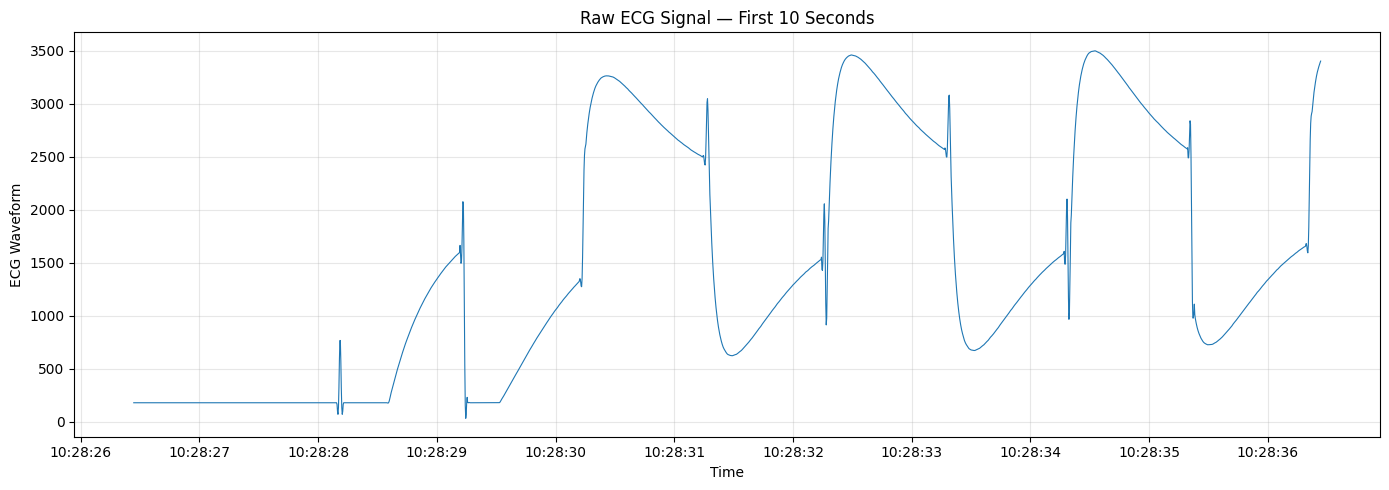

In [ ]:
# Cell 12 — Plot the Raw ECG Signal

import matplotlib.pyplot as plt

# Select the first 10 seconds of the ECG recording
plot_duration_seconds = 10
plot_samples = int(plot_duration_seconds * sampling_frequency)

ecg_plot = ecg_sample.iloc[:plot_samples]

# Create the plot
plt.figure(figsize=(14, 5))

plt.plot(
    ecg_plot["Time"],
    ecg_plot["EcgWaveform"],
    linewidth=0.8
)

plt.title("Raw ECG Signal — First 10 Seconds")
plt.xlabel("Time")
plt.ylabel("ECG Waveform")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.6 Initial Visual Assessment of the Raw ECG

Visual inspection of the first 10 seconds reveals substantial variation in the raw waveform, including prolonged low-level regions, large signal excursions, and repeated transitions toward the upper range of the recorded values. A clear conventional ECG morphology is not readily identifiable from this initial view.

The observed maximum value of 4095 is consistent with the documented raw digital range of the Zephyr ECG waveform. Therefore, the raw values should not yet be interpreted directly as physical ECG amplitude without confirming the appropriate device conversion.

Further signal-quality analysis is required before selecting filtering, normalization, or other preprocessing operations.

In [ ]:
# Cell 13 — Quantify Signal Quality Indicators

# Count samples at the lower and upper limits
min_value = ecg_values.min()
max_value = ecg_values.max()

min_count = (ecg_values == min_value).sum()
max_count = (ecg_values == max_value).sum()

# Calculate consecutive-sample differences
sample_differences = ecg_values.diff().abs().dropna()

# Count consecutive identical samples
unchanged_count = (sample_differences == 0).sum()

print("ECG Signal Quality Indicators\n")

print(f"Minimum observed value: {min_value}")
print(f"Maximum observed value: {max_value}")

print(f"\nSamples equal to minimum: {min_count}")
print(f"Samples equal to maximum: {max_count}")

print(
    f"Percentage at minimum: "
    f"{(min_count / len(ecg_values)) * 100:.4f}%"
)

print(
    f"Percentage at maximum: "
    f"{(max_count / len(ecg_values)) * 100:.4f}%"
)

print(f"\nConsecutive unchanged samples: {unchanged_count}")

print(
    f"Percentage of unchanged transitions: "
    f"{(unchanged_count / len(sample_differences)) * 100:.4f}%"
)

print("\nAbsolute sample-to-sample difference:")
print(sample_differences.describe())

ECG Signal Quality Indicators

Minimum observed value: 10
Maximum observed value: 4095

Samples equal to minimum: 1
Samples equal to maximum: 1
Percentage at minimum: 0.0010%
Percentage at maximum: 0.0010%

Consecutive unchanged samples: 15176
Percentage of unchanged transitions: 15.1762%

Absolute sample-to-sample difference:
count    99999.000000
mean         8.827218
std         68.411574
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       4037.000000
Name: EcgWaveform, dtype: float64


## 2.7 Investigation of Abrupt Signal Transitions

The signal-quality analysis shows that the minimum and maximum recorded values occur only once each, indicating that the observed signal range is not dominated by clipping at the limits.

Approximately 15.18% of consecutive samples have identical waveform values, while most non-zero sample-to-sample changes are relatively small. However, the maximum absolute change between consecutive samples is substantially larger than the typical change.

Before applying any filtering or correction, these abrupt transitions will therefore be examined directly to determine whether they represent signal artefacts, recording discontinuities, or characteristics of the raw digital signal representation.

In [ ]:
# Cell 14 — Investigate Abrupt ECG Transitions

# Calculate absolute sample-to-sample changes
sample_differences = ecg_sample["EcgWaveform"].diff().abs()

# Find the locations of the five largest changes
largest_jumps = sample_differences.nlargest(5)

print("Five largest sample-to-sample changes:\n")

for index, difference in largest_jumps.items():
    print(
        f"Index: {index:,} | "
        f"Difference: {difference:.0f} | "
        f"Previous value: {ecg_sample.loc[index - 1, 'EcgWaveform']} | "
        f"Current value: {ecg_sample.loc[index, 'EcgWaveform']}"
    )

# Select the location of the largest jump
largest_jump_index = largest_jumps.index[0]

# Inspect a small window around the largest jump
window_before = 20
window_after = 20

start_index = max(0, largest_jump_index - window_before)
end_index = min(len(ecg_sample), largest_jump_index + window_after + 1)

jump_window = ecg_sample.iloc[start_index:end_index]

print("\nValues around the largest jump:\n")
display(jump_window)

Five largest sample-to-sample changes:

Index: 34,051 | Difference: 4037 | Previous value: 51 | Current value: 4088
Index: 34,050 | Difference: 4017 | Previous value: 4068 | Current value: 51
Index: 34,061 | Difference: 3984 | Previous value: 31 | Current value: 4015
Index: 98,942 | Difference: 3914 | Previous value: 3949 | Current value: 35
Index: 97,160 | Difference: 3912 | Previous value: 4079 | Current value: 167

Values around the largest jump:



,Time,EcgWaveform
34031,2022-06-06 10:30:42.572,3916
34032,2022-06-06 10:30:42.576,3916
34033,2022-06-06 10:30:42.580,3916
34034,2022-06-06 10:30:42.584,3916
34035,2022-06-06 10:30:42.588,3916
34036,2022-06-06 10:30:42.592,3916
34037,2022-06-06 10:30:42.596,3916
34038,2022-06-06 10:30:42.600,3916
34039,2022-06-06 10:30:42.604,3916
34040,2022-06-06 10:30:42.608,3916


In [ ]:
# Cell 15 — Quantify Constant-Value Runs

signal = ecg_sample["EcgWaveform"]

# Identify where the signal changes
value_changed = signal.ne(signal.shift())

# Create a group number for each consecutive constant-value run
run_id = value_changed.cumsum()

# Calculate the length of every constant-value run
run_lengths = signal.groupby(run_id).transform("size")

# Create a table containing the value and length of each run
constant_runs = pd.DataFrame({
    "Value": signal,
    "RunLength": run_lengths
}).drop_duplicates()

# Keep only the longest constant-value runs
longest_runs = (
    constant_runs
    .sort_values("RunLength", ascending=False)
    .head(15)
)

print("Longest constant-value runs:\n")
display(longest_runs)

print("\nLongest run duration:")
longest_duration = longest_runs["RunLength"].iloc[0] / sampling_frequency
print(f"{longest_duration:.4f} seconds")

Longest constant-value runs:



,Value,RunLength
34063,3916,3021
33550,3916,498
0,179,428
97162,179,245
98952,3916,235
97945,3916,232
99202,179,231
99476,3916,230
98457,3916,229
96670,179,227



Longest run duration:
12.0840 seconds


## 2.8 Identification of Prolonged Constant-Value Segments

The analysis identified prolonged periods in which the ECG waveform remains at exactly the same digital value. The longest observed run contains 3,021 consecutive samples at a value of 3916, corresponding to approximately 12.08 seconds at the confirmed sampling frequency of 250 Hz.

Additional prolonged runs were also observed at values of 3916 and 179. These extended constant-value regions are not treated as ordinary ECG noise. Instead, they are considered potential signal-quality artefacts and will be investigated further.

Because filtering cannot recover physiological information that was not recorded during a prolonged constant segment, the preprocessing strategy will first identify and handle poor-quality regions before applying conventional ECG filtering to valid signal segments.

In [ ]:
# Cell 16 — Quantify Prolonged Flat Segments

# Define a minimum duration for a suspicious constant-value segment
minimum_duration_seconds = 1.0
minimum_run_length = int(minimum_duration_seconds * sampling_frequency)

# Keep only constant-value runs lasting at least the chosen duration
prolonged_runs = constant_runs[
    constant_runs["RunLength"] >= minimum_run_length
].copy()

# Add duration in seconds
prolonged_runs["DurationSeconds"] = (
    prolonged_runs["RunLength"] / sampling_frequency
)

# Calculate the total number of samples contained in prolonged runs
total_prolonged_samples = prolonged_runs["RunLength"].sum()

# Calculate percentage of the inspected signal affected
prolonged_percentage = (
    total_prolonged_samples / len(ecg_sample)
) * 100

print("Prolonged constant-value segments")
print("----------------------------------")
print(f"Minimum duration threshold: {minimum_duration_seconds:.1f} second")
print(f"Minimum run length: {minimum_run_length} samples")
print(f"Number of prolonged segments: {len(prolonged_runs)}")
print(f"Total samples affected: {total_prolonged_samples:,}")
print(f"Percentage of sample affected: {prolonged_percentage:.2f}%")

print("\nLongest prolonged segments:")
display(
    prolonged_runs
    .sort_values("RunLength", ascending=False)
    .head(20)
)

Prolonged constant-value segments
----------------------------------
Minimum duration threshold: 1.0 second
Minimum run length: 250 samples
Number of prolonged segments: 3
Total samples affected: 3,947
Percentage of sample affected: 3.95%

Longest prolonged segments:


,Value,RunLength,DurationSeconds
34063,3916,3021,12.084
33550,3916,498,1.992
0,179,428,1.712


## 2.9 Visual Inspection of Suspected Signal-Quality Artefacts

The previous analysis identified prolonged constant-value segments and unusually large sample-to-sample transitions. Before defining a quality-control rule, the suspicious regions are visualised directly in their temporal context.

This step is used to determine whether the detected regions represent isolated transitions, prolonged signal plateaus, or other recording artefacts. The observations will guide the subsequent signal-quality handling strategy.

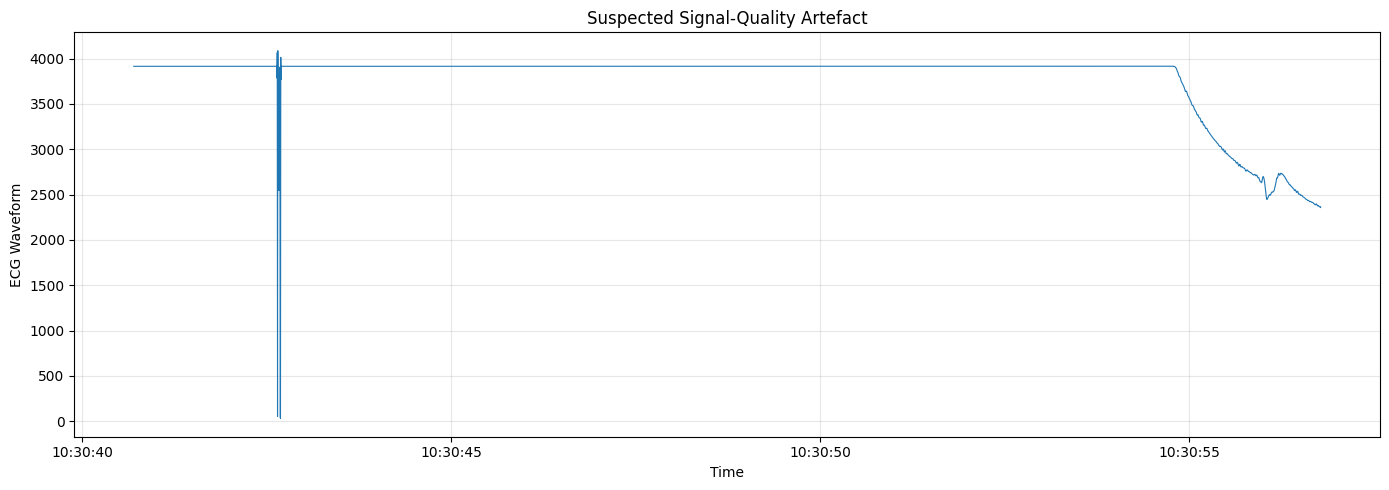

In [ ]:
# Cell 17 — Visualise the Suspicious ECG Region

# Identify the longest constant-value run
longest_run = longest_runs.iloc[0]

# Get the starting index of the longest run
longest_run_start = int(longest_run.name)

# Define a viewing window around the suspicious region
context_before = int(2 * sampling_frequency)
context_after = int(2 * sampling_frequency)

start_index = max(0, longest_run_start - context_before)
end_index = min(
    len(ecg_sample),
    longest_run_start + int(longest_run["RunLength"]) + context_after
)

suspicious_region = ecg_sample.iloc[start_index:end_index]

# Plot the suspicious region
plt.figure(figsize=(14, 5))

plt.plot(
    suspicious_region["Time"],
    suspicious_region["EcgWaveform"],
    linewidth=0.8
)

plt.title("Suspected Signal-Quality Artefact")
plt.xlabel("Time")
plt.ylabel("ECG Waveform")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.10 Cross-Recording Signal Quality Check

The visual inspection confirms that the selected recording contains a prolonged constant-value region followed by an abrupt transition and subsequent signal variation. This behaviour is therefore considered a potential recording-quality issue.

However, a preprocessing rule should not be based on a single ECG recording. A second ECG recording will be inspected to determine whether similar signal behaviour occurs across recordings.

This comparison will help distinguish recording-specific artefacts from characteristics that may be common to the dataset.

Second ECG recording:
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__15_38_43_ECG.csv

Shape:
(100000, 2)

Missing values:
Time           0
EcgWaveform    0
dtype: int64

Signal statistics:
count    100000.000000
mean       2044.619830
std          58.484789
min        1338.000000
25%        2031.000000
50%        2041.000000
75%        2051.000000
max        3870.000000
Name: EcgWaveform, dtype: float64

Percentage of unchanged transitions:
19.00%


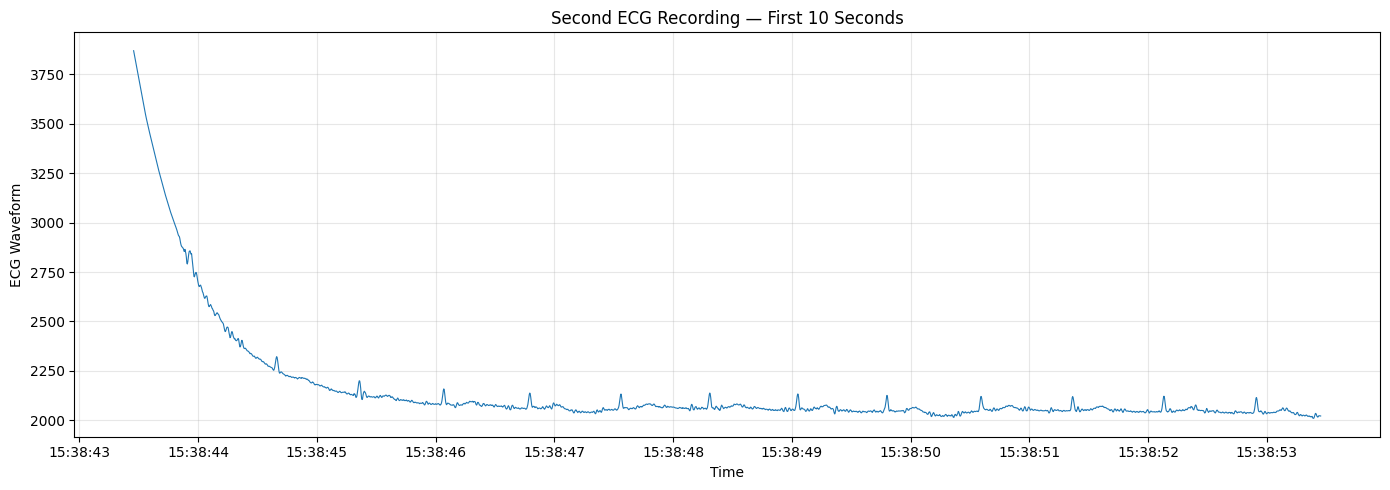

In [ ]:
# Cell 18 — Compare a Second ECG Recording

# Select the second ECG CSV recording
second_ecg_path = ecg_csv_files[1]

# Load the first 100,000 rows of the second recording
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    with zip_ref.open(second_ecg_path) as ecg_file:
        second_ecg_sample = pd.read_csv(
            ecg_file,
            nrows=100_000
        )

# Convert timestamps to datetime
second_ecg_sample["Time"] = pd.to_datetime(
    second_ecg_sample["Time"],
    format="%d/%m/%Y %H:%M:%S.%f"
)

# Basic signal statistics
second_signal = second_ecg_sample["EcgWaveform"]

print("Second ECG recording:")
print(second_ecg_path)

print("\nShape:")
print(second_ecg_sample.shape)

print("\nMissing values:")
print(second_ecg_sample.isna().sum())

print("\nSignal statistics:")
print(second_signal.describe())

# Calculate consecutive differences
second_differences = second_signal.diff().abs().dropna()

print("\nPercentage of unchanged transitions:")
print(
    f"{(second_differences == 0).mean() * 100:.2f}%"
)

# Plot first 10 seconds
second_plot_samples = int(10 * sampling_frequency)

plt.figure(figsize=(14, 5))

plt.plot(
    second_ecg_sample.iloc[:second_plot_samples]["Time"],
    second_ecg_sample.iloc[:second_plot_samples]["EcgWaveform"],
    linewidth=0.8
)

plt.title("Second ECG Recording — First 10 Seconds")
plt.xlabel("Time")
plt.ylabel("ECG Waveform")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.11 Comparison of ECG Recording Quality

The second ECG recording shows substantially different signal behaviour from the first recording. Following an initial transition, the waveform exhibits continuous variation and repeated sharp peaks that are more consistent with an ECG signal.

This comparison demonstrates that prolonged constant-value regions identified in the first recording should not automatically be considered a universal characteristic of the dataset. It also shows that the percentage of unchanged consecutive samples alone is insufficient as a signal-quality criterion.

Therefore, subsequent quality control will focus on identifying prolonged constant-value regions and other localised signal abnormalities rather than rejecting recordings solely on the basis of overall sample-to-sample variability.

In [ ]:
# Cell 19 — Check Prolonged Runs in the Second Recording

second_signal = second_ecg_sample["EcgWaveform"]

# Identify changes between consecutive samples
second_changed = second_signal.ne(second_signal.shift())

# Create groups for consecutive identical values
second_run_id = second_changed.cumsum()

# Calculate the length of each constant-value run
second_run_lengths = second_signal.groupby(second_run_id).transform("size")

# Create a table of constant-value runs
second_constant_runs = pd.DataFrame({
    "Value": second_signal,
    "RunLength": second_run_lengths
}).drop_duplicates()

# Use the same 1-second investigation threshold
minimum_run_length = int(1.0 * sampling_frequency)

second_prolonged_runs = second_constant_runs[
    second_constant_runs["RunLength"] >= minimum_run_length
].copy()

second_prolonged_runs["DurationSeconds"] = (
    second_prolonged_runs["RunLength"] / sampling_frequency
)

print("Second recording — prolonged constant-value segments")
print("----------------------------------------------------")
print(f"Number of segments >= 1 second: {len(second_prolonged_runs)}")

if len(second_prolonged_runs) > 0:
    print("\nLongest prolonged segments:")
    display(
        second_prolonged_runs
        .sort_values("RunLength", ascending=False)
        .head(15)
    )
else:
    print("\nNo constant-value segment of 1 second or longer was found.")

Second recording — prolonged constant-value segments
----------------------------------------------------
Number of segments >= 1 second: 0

No constant-value segment of 1 second or longer was found.


## 2.12 Signal-Quality Handling Strategy

Comparison of two ECG recordings showed that prolonged constant-value regions are recording-specific rather than a universal characteristic of the dataset. The first recording contained a prolonged constant segment lasting approximately 12.08 seconds, whereas the second recording contained no constant-value segment lasting one second or longer.

Therefore, the preprocessing pipeline will use local signal-quality detection rather than applying a blanket correction to all recordings. Prolonged constant-value regions will be flagged as potentially invalid rather than replaced with artificially generated ECG values.

The remaining valid signal will then undergo appropriate ECG filtering, with the raw and processed signals compared to assess the effect of preprocessing.

In [ ]:
# Cell 20 — Create a Quality Mask for the First Recording

# Start by treating every sample as potentially valid
quality_mask = pd.Series(
    True,
    index=ecg_sample.index
)

# Use the previously identified 1-second investigation threshold
minimum_run_length = int(1.0 * sampling_frequency)

# Identify constant-value runs in the first recording
signal = ecg_sample["EcgWaveform"]
changed = signal.ne(signal.shift())
run_id = changed.cumsum()

run_lengths = signal.groupby(run_id).transform("size")

# Mark prolonged constant-value regions as potentially invalid
quality_mask[run_lengths >= minimum_run_length] = False

# Add the quality mask to the ECG dataframe
ecg_sample["QualityValid"] = quality_mask

# Summarise the result
invalid_samples = (~ecg_sample["QualityValid"]).sum()
valid_samples = ecg_sample["QualityValid"].sum()

print("Quality mask created successfully.\n")

print(f"Total samples: {len(ecg_sample):,}")
print(f"Potentially valid samples: {valid_samples:,}")
print(f"Potentially invalid samples: {invalid_samples:,}")

print(
    f"Percentage potentially invalid: "
    f"{(invalid_samples / len(ecg_sample)) * 100:.2f}%"
)

Quality mask created successfully.

Total samples: 100,000
Potentially valid samples: 96,053
Potentially invalid samples: 3,947
Percentage potentially invalid: 3.95%


## 2.13 Validation of the Signal-Quality Mask

A quality mask was created to identify prolonged constant-value regions lasting at least one second. In the inspected recording, 3,947 of 100,000 samples (3.95%) were flagged as potentially invalid.

The original ECG values have been retained, and the quality mask is stored separately. Before using the mask in subsequent preprocessing, its location will be visually validated against the raw ECG waveform to ensure that the detected regions correspond to the previously identified signal-quality artefacts.

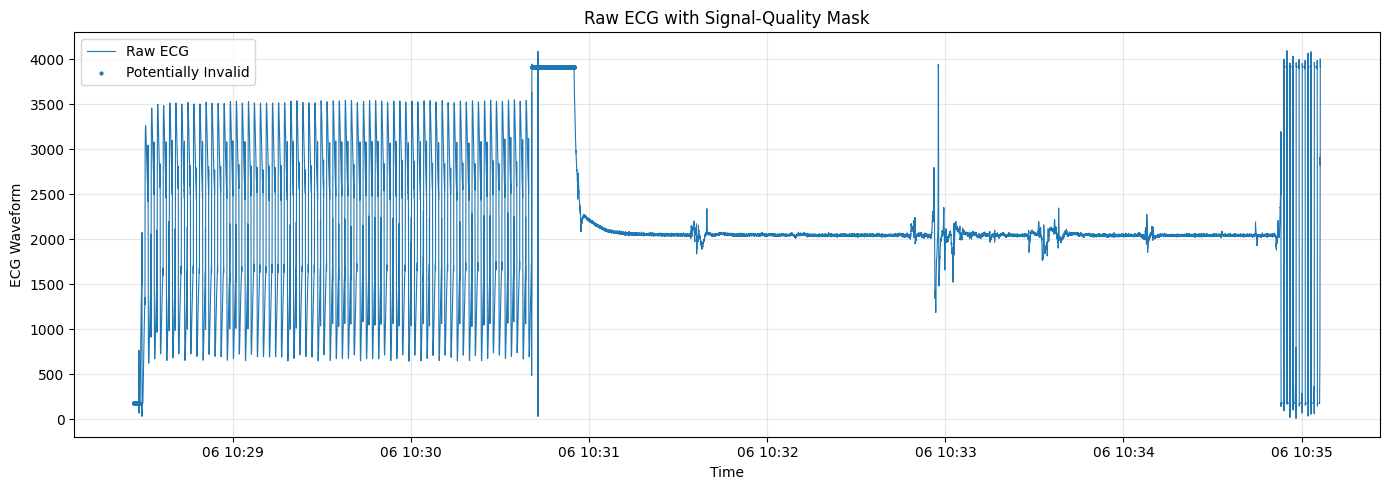

In [ ]:
# Cell 21 — Visualise the Quality Mask

# Plot the first recording with invalid regions highlighted
plt.figure(figsize=(14, 5))

# Plot the original ECG signal
plt.plot(
    ecg_sample["Time"],
    ecg_sample["EcgWaveform"],
    linewidth=0.8,
    label="Raw ECG"
)

# Highlight potentially invalid samples
invalid_region = ecg_sample[~ecg_sample["QualityValid"]]

plt.scatter(
    invalid_region["Time"],
    invalid_region["EcgWaveform"],
    s=4,
    label="Potentially Invalid"
)

plt.title("Raw ECG with Signal-Quality Mask")
plt.xlabel("Time")
plt.ylabel("ECG Waveform")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.14 Separation of Valid and Invalid Signal Regions

The quality-mask visualisation confirms that the prolonged constant-value region identified during signal-quality analysis has been correctly flagged. Other transient signal excursions remain unclassified at this stage and are therefore retained for further investigation.

The invalid regions will not be replaced with interpolated values. Instead, they will be separated from the valid ECG signal so that subsequent filtering can be applied only to continuous valid sections. This prevents the filtering operation from treating a prolonged recording gap or artefact as genuine physiological data.

In [ ]:
# Cell 22 — Create the Quality-Controlled ECG Signal

# Keep the original ECG waveform unchanged
ecg_sample["EcgWaveform_Raw"] = ecg_sample["EcgWaveform"]

# Create a quality-controlled version
# Invalid regions are represented as NaN rather than being replaced
ecg_sample["EcgWaveform_QC"] = ecg_sample["EcgWaveform"].where(
    ecg_sample["QualityValid"],
    np.nan
)

# Count valid and invalid values
valid_count = ecg_sample["EcgWaveform_QC"].notna().sum()
invalid_count = ecg_sample["EcgWaveform_QC"].isna().sum()

print("Quality-controlled ECG created successfully.\n")

print(f"Raw ECG samples: {len(ecg_sample):,}")
print(f"Valid ECG samples: {valid_count:,}")
print(f"Invalid ECG samples: {invalid_count:,}")

print("\nColumns now available:")
print(ecg_sample.columns.tolist())

Quality-controlled ECG created successfully.

Raw ECG samples: 100,000
Valid ECG samples: 96,053
Invalid ECG samples: 3,947

Columns now available:
['Time', 'EcgWaveform', 'QualityValid', 'EcgWaveform_Raw', 'EcgWaveform_QC']


## 2.15 Identification of Continuous Valid ECG Segments

The quality-controlled ECG retains the original waveform while representing detected poor-quality regions as missing values. Before applying digital filtering, the continuous valid portions of the recording must be identified.

Filtering will be performed separately on continuous valid segments rather than across invalid gaps. This prevents the filtering operation from introducing artificial behaviour at the boundaries of poor-quality regions.

In [ ]:
# Cell 23 — Identify Continuous Valid ECG Segments

# Identify whether each sample is valid
valid_samples = ecg_sample["EcgWaveform_QC"].notna()

# Detect where the validity status changes
validity_change = valid_samples.ne(valid_samples.shift())

# Create a group for each continuous valid/invalid section
segment_id = validity_change.cumsum()

# Calculate the length of each section
segment_lengths = valid_samples.groupby(segment_id).transform("size")

# Create a summary table
segments = pd.DataFrame({
    "SegmentID": segment_id,
    "Valid": valid_samples,
    "LengthSamples": segment_lengths
}).drop_duplicates()

# Add duration in seconds
segments["DurationSeconds"] = (
    segments["LengthSamples"] / sampling_frequency
)

# Display the valid segments
valid_segments = segments[segments["Valid"]].copy()

print("Continuous valid ECG segments:")
print("--------------------------------")

print(f"Number of valid segments: {len(valid_segments)}")

print("\nValid segment summary:")
display(
    valid_segments[
        ["SegmentID", "Valid", "LengthSamples", "DurationSeconds"]
    ]
    .sort_values(
        "LengthSamples",
        ascending=False
    )
    .rename(columns={
        "SegmentID": "Segment ID",
        "LengthSamples": "Length Samples",
        "DurationSeconds": "Duration (Seconds)"
    })
)


Continuous valid ECG segments:
--------------------------------
Number of valid segments: 3

Valid segment summary:


,Segment ID,Valid,Length Samples,Duration (Seconds)
37084,6,True,62916,251.664
428,2,True,33122,132.488
34048,4,True,15,0.060


## 2.16 Frequency-Domain Inspection of the ECG

Before selecting filter parameters, the frequency content of the valid ECG signal is examined. This allows the preprocessing strategy to be informed by the characteristics of the recorded signal rather than using arbitrary cutoff frequencies.

The largest continuous valid ECG segment is used for this analysis. The power spectral density is calculated to identify the distribution of signal energy across frequencies and to support the selection of appropriate filtering parameters.

Largest continuous valid ECG segment:
Segment ID: 6
Samples: 62,916
Duration: 251.66 seconds


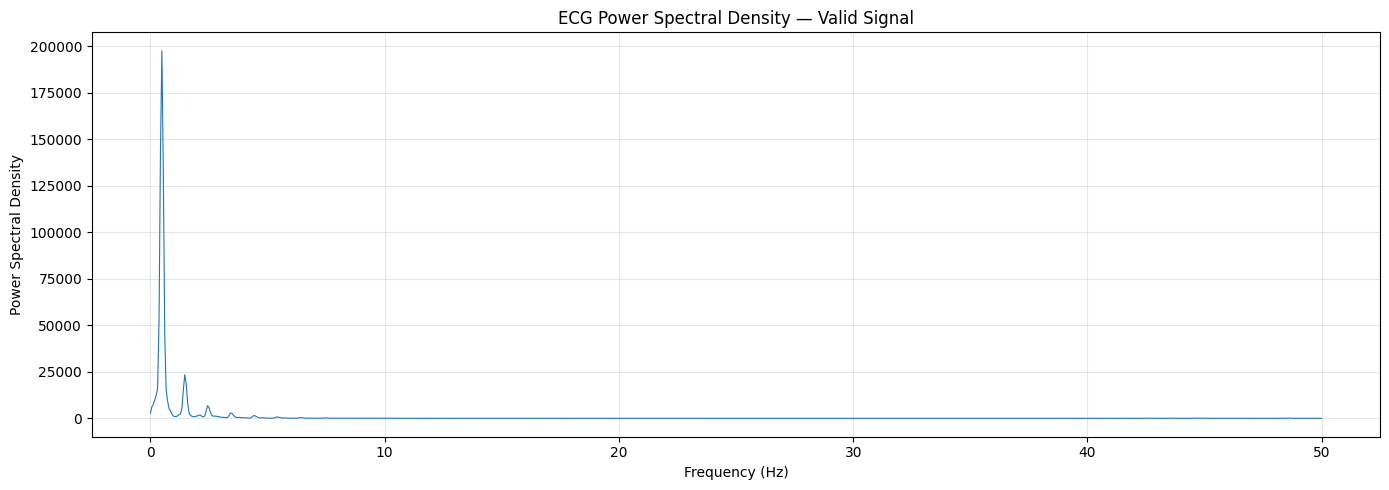

In [ ]:
# Cell 24 — Inspect ECG Frequency Content

from scipy.signal import welch

# Identify the largest continuous valid segment
largest_segment_id = valid_segments.sort_values(
    "LengthSamples",
    ascending=False
).iloc[0]["SegmentID"]

largest_segment = ecg_sample[
    (segment_id == largest_segment_id) &
    (ecg_sample["QualityValid"])
]["EcgWaveform_QC"].dropna()

print("Largest continuous valid ECG segment:")
print(f"Segment ID: {int(largest_segment_id)}")
print(f"Samples: {len(largest_segment):,}")
print(f"Duration: {len(largest_segment) / sampling_frequency:.2f} seconds")

# Calculate the power spectral density
frequencies, power = welch(
    largest_segment.to_numpy(),
    fs=sampling_frequency,
    nperseg=4096
)

# Plot frequencies up to 50 Hz
frequency_limit = 50
frequency_mask = frequencies <= frequency_limit

plt.figure(figsize=(14, 5))

plt.plot(
    frequencies[frequency_mask],
    power[frequency_mask],
    linewidth=0.8
)

plt.title("ECG Power Spectral Density — Valid Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.17 Frequency Content After Removing the Signal Offset

The initial power spectral density shows a strong concentration of signal energy at very low frequencies. However, the raw ECG waveform contains a substantial signal offset, which can dominate the low-frequency portion of the spectrum.

To distinguish the signal offset and very-low-frequency components from the remaining waveform content, the median signal level will be removed before repeating the frequency-domain analysis. This provides a clearer view of the frequency components that vary around the central signal level.

This step is performed for analysis only; the original ECG data are not modified.

Five strongest frequency components below 50 Hz:

Frequency: 0.488 Hz | Power: 197537.22
Frequency: 0.427 Hz | Power: 143420.29
Frequency: 0.549 Hz | Power: 132320.73
Frequency: 0.366 Hz | Power: 52267.32
Frequency: 0.610 Hz | Power: 44951.47


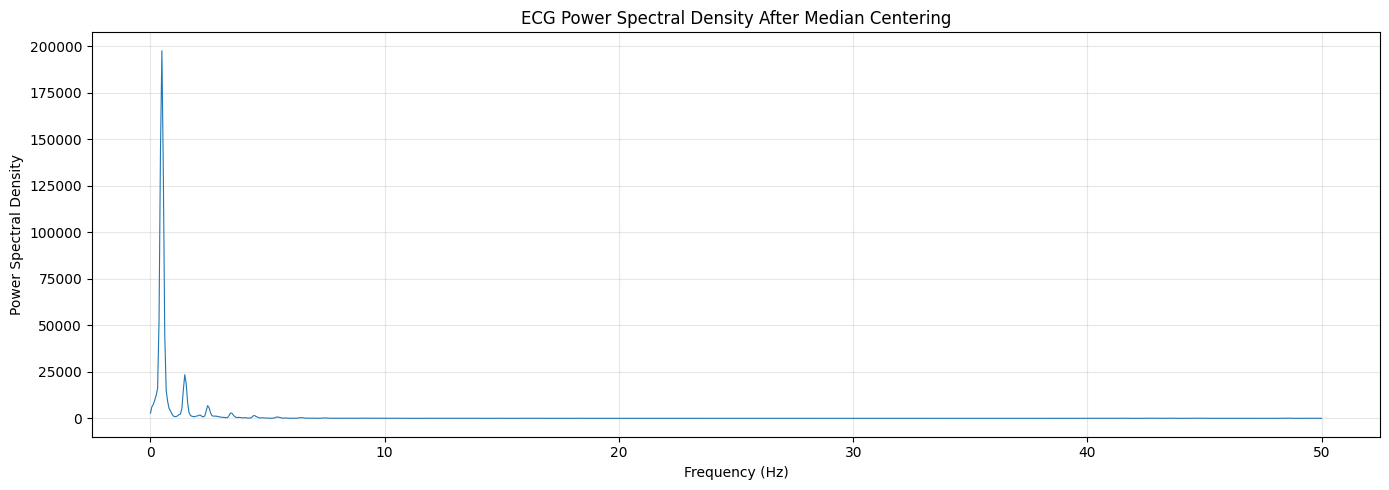

In [ ]:
# Cell 25 — Re-examine Frequency Content After Centering

# Convert the valid ECG segment to a NumPy array
valid_signal = largest_segment.to_numpy()

# Remove the median signal level for frequency analysis
centered_signal = valid_signal - np.median(valid_signal)

# Calculate the power spectral density again
centered_frequencies, centered_power = welch(
    centered_signal,
    fs=sampling_frequency,
    nperseg=4096
)

# Display the dominant frequencies below 50 Hz
frequency_limit = 50
frequency_mask = centered_frequencies <= frequency_limit

# Find the five strongest frequency components
power_in_range = centered_power[frequency_mask]
frequencies_in_range = centered_frequencies[frequency_mask]

top_indices = np.argsort(power_in_range)[-5:][::-1]

print("Five strongest frequency components below 50 Hz:\n")

for i in top_indices:
    print(
        f"Frequency: {frequencies_in_range[i]:.3f} Hz | "
        f"Power: {power_in_range[i]:.2f}"
    )

# Plot the centred signal spectrum
plt.figure(figsize=(14, 5))

plt.plot(
    frequencies_in_range,
    power_in_range,
    linewidth=0.8
)

plt.title("ECG Power Spectral Density After Median Centering")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.18 Detailed Inspection of the ECG Frequency Range

The centred power spectral density shows that the strongest spectral components occur at low frequencies, with progressively lower spectral power at higher frequencies.

Because the dominant low-frequency components may include both physiological variation and baseline-related effects, the spectrum will be examined in greater detail over the lower ECG frequency range before selecting filter boundaries.

This analysis will be used to support, rather than arbitrarily determine, the subsequent filtering strategy.

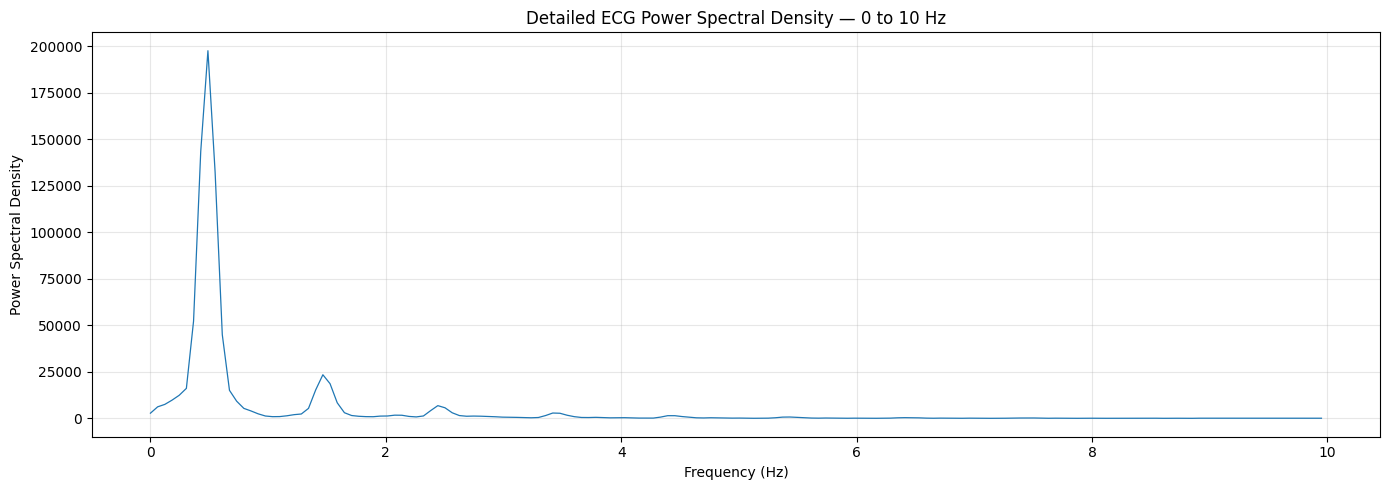

In [ ]:
# Cell 26 — Zoom Into the Low-Frequency ECG Spectrum

# Focus on frequencies between 0 and 10 Hz
zoom_limit = 10
zoom_mask = centered_frequencies <= zoom_limit

plt.figure(figsize=(14, 5))

plt.plot(
    centered_frequencies[zoom_mask],
    centered_power[zoom_mask],
    linewidth=0.9
)

plt.title("Detailed ECG Power Spectral Density — 0 to 10 Hz")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.19 Frequency Analysis of a Stable ECG Region

The previous frequency-domain analysis was performed over a long valid segment that contained substantial low-frequency signal variation. Such slow transitions can dominate the power spectral density and may not represent the normal ECG morphology.

To reduce the influence of these transient effects, a shorter stable region from the middle of the continuous valid segment will be analysed separately. This provides a more representative estimate of the frequency content of the ECG during relatively stable recording conditions.

Stable ECG region:
Duration: 30.00 seconds
Samples: 7,500
Mean: 2042.90
Median: 2046.00
Standard deviation: 180.03


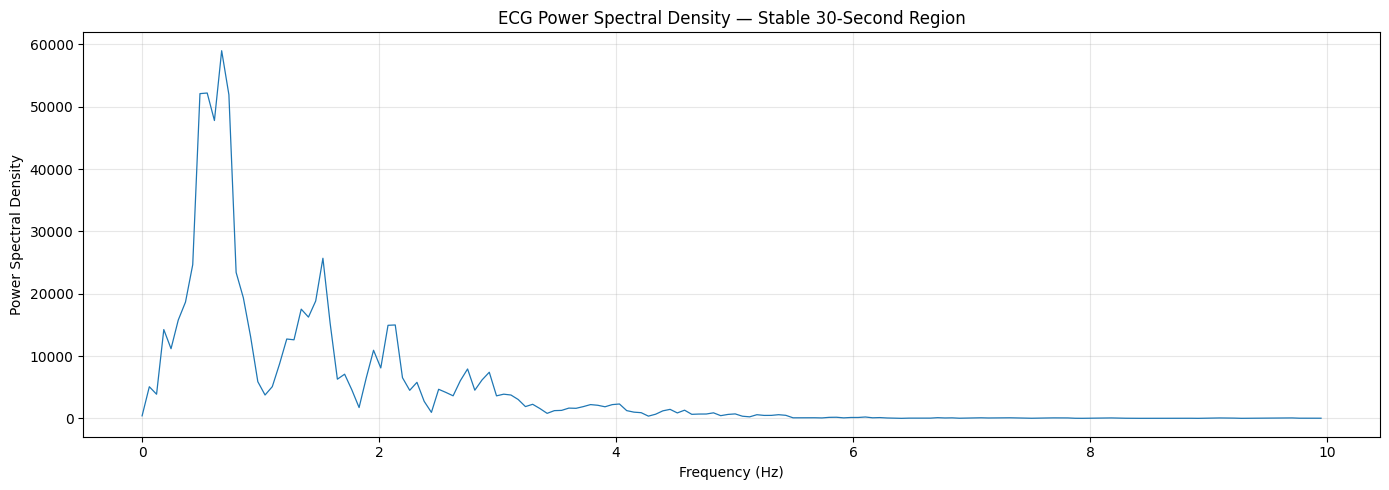

In [ ]:
# Cell 27 — Frequency Analysis of a Stable ECG Region

# Select a 30-second region from the middle of the largest valid segment
stable_duration_seconds = 30
stable_samples = int(stable_duration_seconds * sampling_frequency)

middle_index = len(largest_segment) // 2

stable_start = middle_index - (stable_samples // 2)
stable_end = stable_start + stable_samples

stable_ecg = largest_segment.iloc[stable_start:stable_end].to_numpy()

# Centre the stable signal around its median
stable_ecg_centered = stable_ecg - np.median(stable_ecg)

print("Stable ECG region:")
print(f"Duration: {len(stable_ecg) / sampling_frequency:.2f} seconds")
print(f"Samples: {len(stable_ecg):,}")
print(f"Mean: {np.mean(stable_ecg):.2f}")
print(f"Median: {np.median(stable_ecg):.2f}")
print(f"Standard deviation: {np.std(stable_ecg):.2f}")

# Calculate power spectral density
stable_frequencies, stable_power = welch(
    stable_ecg_centered,
    fs=sampling_frequency,
    nperseg=4096
)

# Focus on 0–10 Hz
stable_mask = stable_frequencies <= 10

# Plot the stable-region spectrum
plt.figure(figsize=(14, 5))

plt.plot(
    stable_frequencies[stable_mask],
    stable_power[stable_mask],
    linewidth=0.9
)

plt.title("ECG Power Spectral Density — Stable 30-Second Region")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.20 Check for 50 Hz Mains Interference

Electrical mains interference can introduce a narrow spectral component around 50 Hz. Since the recordings are being analysed in a UK context, the power at approximately 50 Hz is checked before deciding whether a notch filter is necessary.

A notch filter will only be applied if the frequency-domain evidence indicates meaningful 50 Hz interference.

In [ ]:
# Cell 28 — Check for 50 Hz Mains Interference

# Find the frequency component closest to 50 Hz
target_frequency = 50.0

frequency_index = np.argmin(
    np.abs(centered_frequencies - target_frequency)
)

nearest_frequency = centered_frequencies[frequency_index]
power_at_50hz = centered_power[frequency_index]

# Compare 50 Hz power with the strongest component
strongest_power = np.max(centered_power)
relative_power = (power_at_50hz / strongest_power) * 100

print("50 Hz Mains Interference Check")
print("--------------------------------")
print(f"Nearest frequency analysed: {nearest_frequency:.3f} Hz")
print(f"Power at approximately 50 Hz: {power_at_50hz:.2f}")
print(f"Strongest spectral power: {strongest_power:.2f}")
print(f"50 Hz power relative to strongest component: {relative_power:.4f}%")

if relative_power > 1:
    print("\nResult: A noticeable 50 Hz component is present.")
    print("A notch filter may be considered during preprocessing.")
else:
    print("\nResult: No strong 50 Hz component is evident.")
    print("A 50 Hz notch filter is not currently justified.")

50 Hz Mains Interference Check
--------------------------------
Nearest frequency analysed: 49.988 Hz
Power at approximately 50 Hz: 18.64
Strongest spectral power: 197537.22
50 Hz power relative to strongest component: 0.0094%

Result: No strong 50 Hz component is evident.
A 50 Hz notch filter is not currently justified.


## 2.21 Stage 3 Conclusion — ECG Signal Inspection

The ECG recordings were inspected to characterise their structure, sampling behaviour, signal range, missing values, and signal-quality characteristics. The recordings were found to have a sampling frequency of approximately 250 Hz, with ECG waveform values stored as sensor-level integer measurements rather than direct physiological voltage units.

Signal-quality analysis identified prolonged constant-value regions in the representative recording. These regions were flagged using a quality mask and separated from continuous valid ECG segments without modifying the original raw signal.

Frequency-domain analysis showed that most signal energy was concentrated at lower frequencies, providing evidence for subsequent baseline-wander and noise filtering. A dedicated check for mains interference found negligible spectral power around 50 Hz (0.0094% of the strongest spectral component). Therefore, a 50 Hz notch filter is not justified for the current preprocessing pipeline.

The signal inspection stage is therefore complete, and the next stage will apply the selected preprocessing operations to the continuous valid ECG regions.

# 3. ECG Signal Preprocessing

## 3.1 Filter Design

Based on the signal inspection and frequency-domain analysis, a band-pass filtering strategy will be used to reduce slow baseline variation and high-frequency noise while preserving the main ECG waveform components.

A high-pass cutoff of 0.5 Hz will be used to reduce baseline wander, while a low-pass cutoff of 40 Hz will be used to reduce higher-frequency noise. A 50 Hz notch filter will not be applied because the preceding analysis found negligible spectral power around the mains frequency.

The filters will be applied using zero-phase filtering to minimise phase distortion of the ECG waveform.

In [ ]:
# Cell 29 — Design the ECG Band-Pass Filter

from scipy.signal import butter, sosfiltfilt

# Filter parameters
low_cutoff = 0.5      # Hz
high_cutoff = 40.0    # Hz
filter_order = 4

# Design a Butterworth band-pass filter
sos = butter(
    filter_order,
    [low_cutoff, high_cutoff],
    btype="bandpass",
    fs=sampling_frequency,
    output="sos"
)

print("ECG band-pass filter designed successfully.\n")

print(f"Sampling frequency: {sampling_frequency:.2f} Hz")
print(f"Low cutoff: {low_cutoff:.2f} Hz")
print(f"High cutoff: {high_cutoff:.2f} Hz")
print(f"Filter order: {filter_order}")
print("Filter type: Butterworth band-pass")
print("Filtering method: Zero-phase SOS filtering")

ECG band-pass filter designed successfully.

Sampling frequency: 250.00 Hz
Low cutoff: 0.50 Hz
High cutoff: 40.00 Hz
Filter order: 4
Filter type: Butterworth band-pass
Filtering method: Zero-phase SOS filtering


## 3.2 Apply Band-Pass Filtering to Valid ECG Segments

The designed Butterworth band-pass filter is applied separately to each continuous valid ECG segment. This prevents the filtering operation from crossing the signal-quality gaps identified during the inspection stage.

The original raw ECG and quality mask are retained unchanged. The filtered signal is stored in a separate column for subsequent validation and analysis.

In [ ]:
# Cell 30 — Apply Band-Pass Filter to Valid ECG Segments

# Create a new column for the filtered ECG
ecg_sample["EcgWaveform_Filtered"] = np.nan

# Minimum number of samples required by sosfiltfilt
minimum_filter_length = 28

# Apply the filter separately to each continuous valid segment
for current_segment_id in valid_segments["SegmentID"]:

    segment_mask = (
        (segment_id == current_segment_id) &
        (ecg_sample["QualityValid"])
    )

    segment_values = ecg_sample.loc[
        segment_mask,
        "EcgWaveform_QC"
    ].to_numpy()

    # Skip segments that are too short for filtering
    if len(segment_values) <= minimum_filter_length:
        print(
            f"Skipping Segment {int(current_segment_id)}: "
            f"{len(segment_values)} samples"
        )
        continue

    # Apply zero-phase filtering
    filtered_values = sosfiltfilt(
        sos,
        segment_values
    )

    # Store filtered values
    ecg_sample.loc[
        segment_mask,
        "EcgWaveform_Filtered"
    ] = filtered_values

# Count successfully filtered samples
filtered_count = ecg_sample["EcgWaveform_Filtered"].notna().sum()

print("\nBand-pass filtering completed successfully.\n")

print(f"Total ECG samples: {len(ecg_sample):,}")
print(f"Filtered samples: {filtered_count:,}")
print(
    f"Unfiltered/invalid samples: "
    f"{len(ecg_sample) - filtered_count:,}"
)

Skipping Segment 4: 15 samples

Band-pass filtering completed successfully.

Total ECG samples: 100,000
Filtered samples: 96,038
Unfiltered/invalid samples: 3,962


## 3.3 Validation of the Filtered ECG

The filtered ECG is compared with the corresponding raw signal to assess the effect of the band-pass filter. The comparison focuses on whether slow baseline variation and high-frequency noise have been reduced while the overall waveform structure remains preserved.

The raw signal is retained as a reference, allowing the effect of preprocessing to be evaluated before further processing.

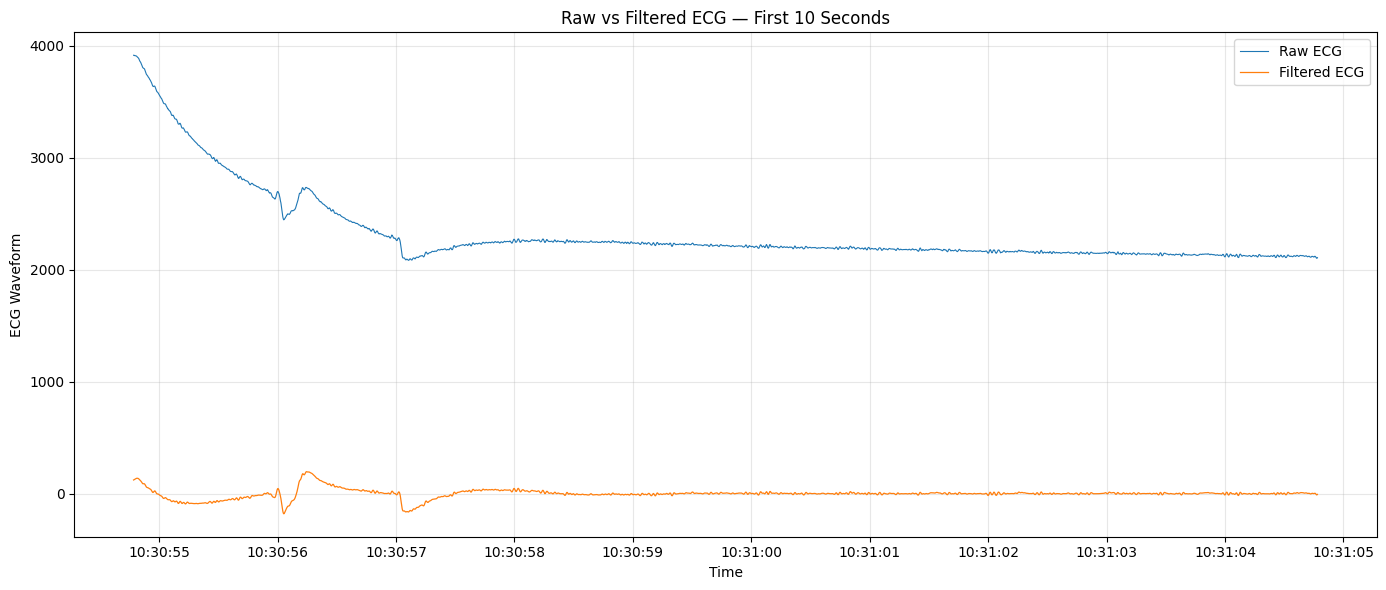

In [ ]:
# Cell 31 — Compare Raw vs Filtered ECG

# Select the largest valid segment
comparison_mask = (
    (segment_id == largest_segment_id) &
    (ecg_sample["QualityValid"])
)

comparison_data = ecg_sample.loc[
    comparison_mask
].copy()

# Plot the first 10 seconds of the segment
comparison_samples = int(10 * sampling_frequency)

comparison_data = comparison_data.iloc[:comparison_samples]

plt.figure(figsize=(14, 6))

plt.plot(
    comparison_data["Time"],
    comparison_data["EcgWaveform_Raw"],
    linewidth=0.8,
    label="Raw ECG"
)

plt.plot(
    comparison_data["Time"],
    comparison_data["EcgWaveform_Filtered"],
    linewidth=0.9,
    label="Filtered ECG"
)

plt.title("Raw vs Filtered ECG — First 10 Seconds")
plt.xlabel("Time")
plt.ylabel("ECG Waveform")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.4 Validation of Filtering in a Stable ECG Region

The raw and filtered ECG signals show that the band-pass filter substantially reduces the large baseline variation present in the raw sensor-level signal. A transient response is visible near the beginning of the recording, coinciding with a large change in the original signal.

To avoid evaluating the filter using this initial transition, a stable portion of the recording will be inspected separately. The purpose is to confirm that the filtering preserves the repeating ECG waveform structure after the transient region.

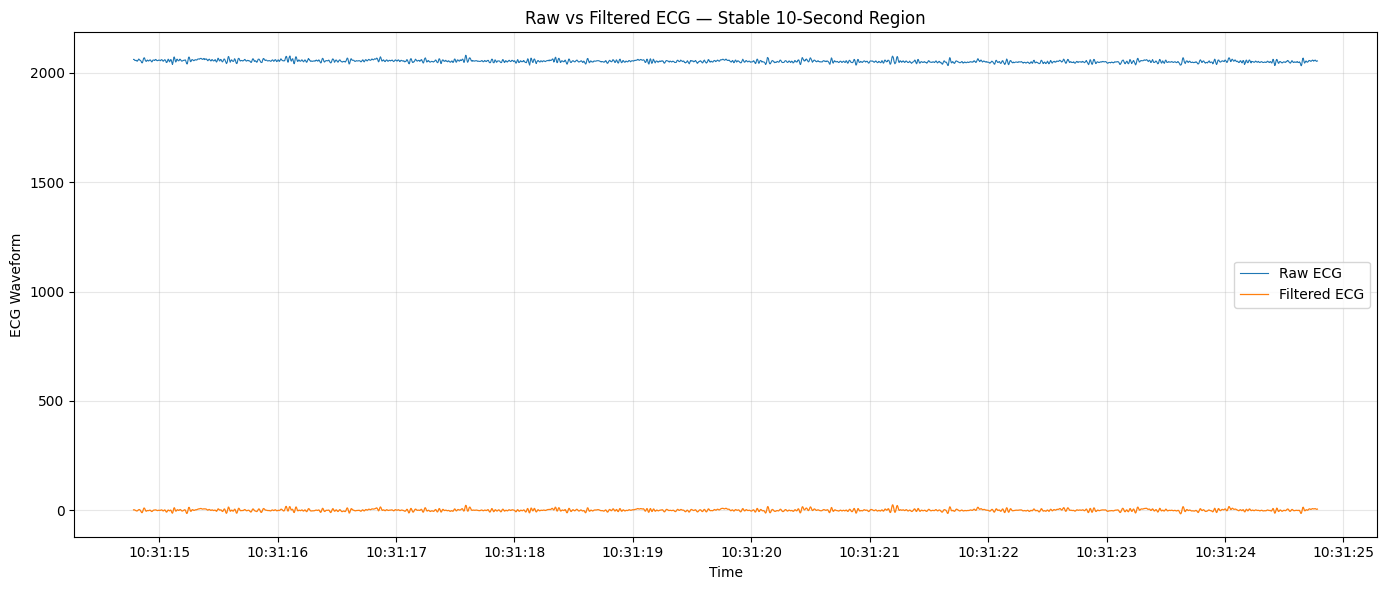

In [ ]:
# Cell 32 — Validate the Filtered ECG in a Stable Region

# Use the same largest valid segment
stable_comparison = ecg_sample.loc[
    comparison_mask
].copy()

# Select a stable region after the initial transient
start_after_seconds = 20
validation_duration_seconds = 10

start_sample = int(start_after_seconds * sampling_frequency)
validation_samples = int(
    validation_duration_seconds * sampling_frequency
)

validation_data = stable_comparison.iloc[
    start_sample:start_sample + validation_samples
]

plt.figure(figsize=(14, 6))

plt.plot(
    validation_data["Time"],
    validation_data["EcgWaveform_Raw"],
    linewidth=0.8,
    label="Raw ECG"
)

plt.plot(
    validation_data["Time"],
    validation_data["EcgWaveform_Filtered"],
    linewidth=0.9,
    label="Filtered ECG"
)

plt.title("Raw vs Filtered ECG — Stable 10-Second Region")
plt.xlabel("Time")
plt.ylabel("ECG Waveform")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.5 Cross-Recording Validation of Filtering

The stable region selected from the first ECG recording shows limited visible waveform variation after removal of the large baseline component. Therefore, this region alone is insufficient for assessing preservation of ECG morphology.

A second ECG recording from the same participant previously demonstrated clearer repeating waveform features and contained no prolonged constant-value segment. The same filtering approach will therefore be applied to this independent recording to assess whether the preprocessing preserves its observable ECG structure.

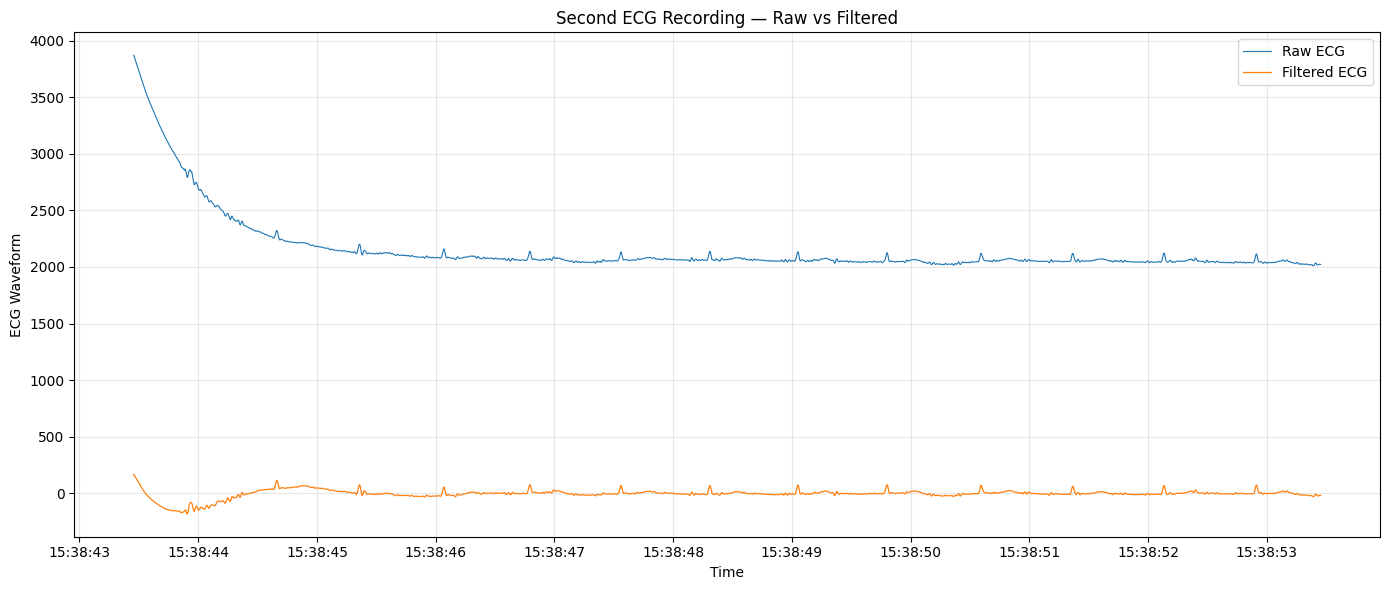

In [ ]:
# Cell 33 — Validate the Filter on the Second ECG Recording

second_signal = second_ecg_sample["EcgWaveform"].to_numpy()

# Apply the same band-pass filter
second_filtered = sosfiltfilt(
    sos,
    second_signal
)

# Store the filtered version
second_ecg_sample["EcgWaveform_Filtered"] = second_filtered

# Plot the first 10 seconds
comparison_samples = int(10 * sampling_frequency)

plt.figure(figsize=(14, 6))

plt.plot(
    second_ecg_sample["Time"].iloc[:comparison_samples],
    second_ecg_sample["EcgWaveform"].iloc[:comparison_samples],
    linewidth=0.8,
    label="Raw ECG"
)

plt.plot(
    second_ecg_sample["Time"].iloc[:comparison_samples],
    second_ecg_sample["EcgWaveform_Filtered"].iloc[:comparison_samples],
    linewidth=0.9,
    label="Filtered ECG"
)

plt.title("Second ECG Recording — Raw vs Filtered")
plt.xlabel("Time")
plt.ylabel("ECG Waveform")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.6 Filtering Validation Conclusion

The band-pass filter was validated using both the representative recording and an independent ECG recording from the same participant. The filtering substantially reduced the large baseline component while retaining the observable repeating waveform characteristics of the second recording.

The filtering was applied only to continuous valid ECG segments, preventing the operation from crossing identified poor-quality gaps. The original raw signal remains preserved for comparison.

The 0.5–40 Hz Butterworth band-pass filter is therefore retained for the subsequent preprocessing pipeline. No 50 Hz notch filter is included because the preceding frequency analysis found negligible mains-frequency interference.

In [ ]:
# Cell 34 — Inspect Filtered ECG Statistics

filtered_signal = ecg_sample[
    "EcgWaveform_Filtered"
].dropna()

print("Filtered ECG statistics")
print("------------------------")

print(f"Valid filtered samples: {len(filtered_signal):,}")
print(f"Minimum: {filtered_signal.min():.4f}")
print(f"Maximum: {filtered_signal.max():.4f}")
print(f"Mean: {filtered_signal.mean():.4f}")
print(f"Median: {filtered_signal.median():.4f}")
print(f"Standard deviation: {filtered_signal.std():.4f}")

print("\nPercentiles:")
print(filtered_signal.quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
))

Filtered ECG statistics
------------------------
Valid filtered samples: 96,038
Minimum: -2198.9459
Maximum: 2199.1402
Mean: 0.0420
Median: -0.2977
Standard deviation: 385.0818

Percentiles:
0.01   -984.852882
0.05   -723.545352
0.25    -12.042839
0.50     -0.297666
0.75     12.238328
0.95    735.697468
0.99    971.865948
Name: EcgWaveform_Filtered, dtype: float64


# 4. ECG Segmentation

## 4.1 Segmentation Strategy

Following signal-quality control and band-pass filtering, the continuous ECG recordings are divided into fixed-length windows for subsequent machine learning and deep learning analysis.

A window length of 10 seconds is selected, corresponding to 2,500 samples at the 250 Hz sampling frequency. A 50% overlap is used between consecutive windows to increase the number of available training samples while maintaining temporal continuity.

Segmentation is performed independently within each continuous valid ECG segment. Therefore, windows are not allowed to cross identified invalid or poor-quality regions.

The segmentation parameters are defined before extracting the windows so that the procedure remains reproducible.

In [ ]:
# Cell 35 — Define ECG Segmentation Parameters

# ECG segmentation parameters
window_duration_seconds = 10
overlap_fraction = 0.50

# Convert duration to number of samples
window_size = int(
    window_duration_seconds * sampling_frequency
)

# Calculate step size after applying overlap
step_size = int(
    window_size * (1 - overlap_fraction)
)

print("ECG segmentation parameters")
print("----------------------------")
print(f"Sampling frequency: {sampling_frequency:.0f} Hz")
print(f"Window duration: {window_duration_seconds} seconds")
print(f"Window size: {window_size:,} samples")
print(f"Overlap: {overlap_fraction * 100:.0f}%")
print(f"Step size: {step_size:,} samples")

ECG segmentation parameters
----------------------------
Sampling frequency: 250 Hz
Window duration: 10 seconds
Window size: 2,500 samples
Overlap: 50%
Step size: 1,250 samples


## 4.2 Available Segmentation Windows

Before extracting ECG windows, the number of complete windows available within each continuous valid segment is calculated.

Only complete windows containing the required 2,500 samples are considered. Windows are generated independently within each valid segment and therefore cannot cross signal-quality boundaries.

In [ ]:
# Cell 36 — Calculate Available ECG Windows

print("Available complete ECG windows")
print("--------------------------------")

total_possible_windows = 0

for _, row in valid_segments.iterrows():

    segment_length = int(row["LengthSamples"])

    if segment_length >= window_size:
        number_of_windows = (
            (segment_length - window_size) // step_size
        ) + 1
    else:
        number_of_windows = 0

    total_possible_windows += number_of_windows

    print(
        f"Segment {int(row['SegmentID'])}: "
        f"{segment_length:,} samples → "
        f"{number_of_windows:,} complete windows"
    )

print("\nTotal possible complete windows:", total_possible_windows)

Available complete ECG windows
--------------------------------
Segment 2: 33,122 samples → 25 complete windows
Segment 4: 15 samples → 0 complete windows
Segment 6: 62,916 samples → 49 complete windows

Total possible complete windows: 74


## 4.3 Extract Fixed-Length ECG Windows

The continuous valid ECG segments are divided into fixed-length 10-second windows using the predefined 50% overlap.

Each extracted window contains exactly 2,500 samples. Windows are generated independently within each continuous valid segment, ensuring that no window crosses a signal-quality boundary.

For traceability, each window is assigned a unique window ID and retains its originating segment ID together with its start and end sample positions.

In [ ]:
# Cell 37 — Extract Fixed-Length ECG Windows with Timestamps

ecg_windows = []

window_id = 0

# Participant ID from the representative ECG recording
from pathlib import Path

participant_id = Path(sample_ecg_path).parent.parent.name

for _, row in valid_segments.iterrows():

    current_segment_id = int(row["SegmentID"])

    segment_mask = (
        (segment_id == current_segment_id) &
        (ecg_sample["QualityValid"])
    )

    segment_data = ecg_sample.loc[
        segment_mask
    ].copy()

    # Reset index so windows can be extracted by position
    segment_data = segment_data.reset_index(drop=True)

    segment_length = len(segment_data)

    # Extract complete windows
    for start in range(
        0,
        segment_length - window_size + 1,
        step_size
    ):

        end = start + window_size

        window_data = segment_data.iloc[start:end]

        # Safety check
        if len(window_data) != window_size:
            continue

        # Preserve the actual ECG timestamps
        start_time = window_data["Time"].iloc[0]
        end_time = window_data["Time"].iloc[-1]

        # Middle timestamp of the 10-second ECG window
        center_time = (
            start_time +
            (end_time - start_time) / 2
        )

        ecg_windows.append({
            "WindowID": window_id,
            "ParticipantID": participant_id,
            "SegmentID": current_segment_id,
            "StartSample": start,
            "EndSample": end - 1,
            "StartTime": start_time,
            "EndTime": end_time,
            "CenterTime": center_time,
            "DurationSeconds": window_duration_seconds,
            "ECG": window_data[
                "EcgWaveform_Filtered"
            ].to_numpy()
        })

        window_id += 1

print("ECG window extraction completed successfully.\n")

print(f"Participant ID: {participant_id}")
print(f"Total windows extracted: {len(ecg_windows)}")
print(f"Samples per window: {window_size:,}")
print(f"Duration per window: {window_duration_seconds} seconds")
print(f"Overlap: {overlap_fraction * 100:.0f}%")

print("\nTimestamp information:")
print(f"First window start: {ecg_windows[0]['StartTime']}")
print(f"First window end: {ecg_windows[0]['EndTime']}")
print(f"First window centre: {ecg_windows[0]['CenterTime']}")

ECG window extraction completed successfully.

Participant ID: 001
Total windows extracted: 74
Samples per window: 2,500
Duration per window: 10 seconds
Overlap: 50%

Timestamp information:
First window start: 2022-06-06 10:28:28.160000
First window end: 2022-06-06 10:28:38.156000
First window centre: 2022-06-06 10:28:33.158000


## 4.4 Validate Extracted ECG Windows

The extracted windows are validated to confirm that every window contains the expected number of ECG samples and that the segmentation process has not introduced incomplete or malformed windows.

The window metadata are also inspected to confirm that each window can be traced back to its originating continuous ECG segment.

In [ ]:
# Cell 38 — Validate Extracted ECG Windows

window_lengths = [
    len(window["ECG"])
    for window in ecg_windows
]

segment_counts = {}

for window in ecg_windows:
    segment = window["SegmentID"]
    segment_counts[segment] = segment_counts.get(segment, 0) + 1

print("ECG window validation")
print("----------------------")

print(f"Total windows: {len(ecg_windows)}")
print(f"Minimum window length: {min(window_lengths):,}")
print(f"Maximum window length: {max(window_lengths):,}")
print(f"Expected window length: {window_size:,}")

print("\nWindows per segment:")

for segment, count in sorted(segment_counts.items()):
    print(f"Segment {segment}: {count}")

print("\nAll windows correct length:",
      all(length == window_size for length in window_lengths))

ECG window validation
----------------------
Total windows: 74
Minimum window length: 2,500
Maximum window length: 2,500
Expected window length: 2,500

Windows per segment:
Segment 2: 25
Segment 6: 49

All windows correct length: True


## 4.5 Visual Inspection of an Extracted ECG Window

A representative 10-second ECG window is visualised after filtering and segmentation. This provides a final visual check that the extracted fixed-length sample retains the temporal structure of the processed ECG before standardisation and subsequent machine learning preparation.

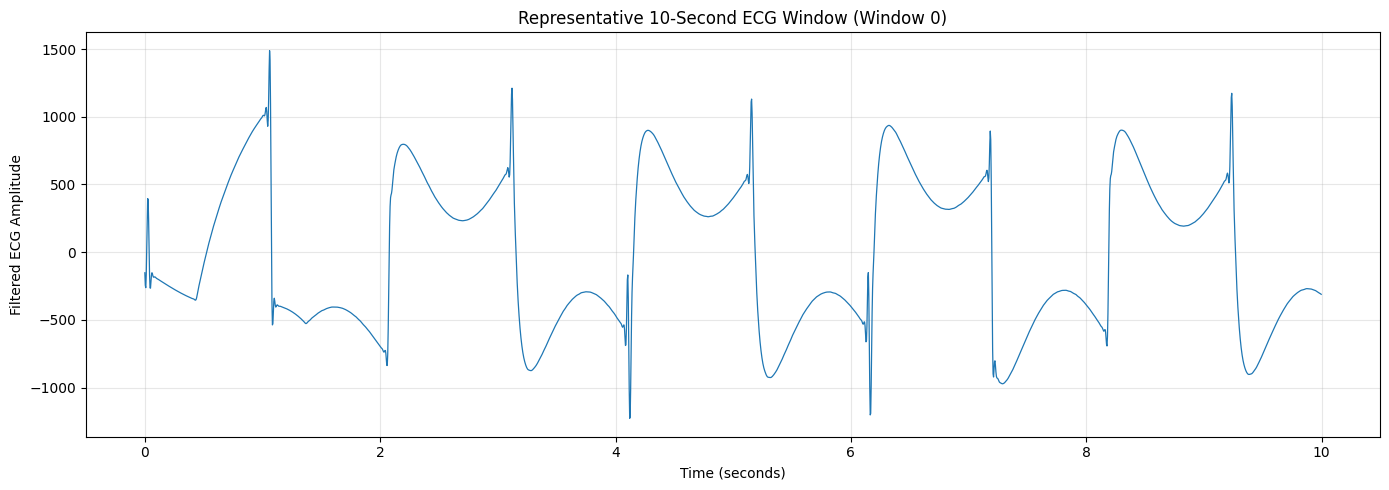

In [ ]:
# Cell 39 — Visualise a Representative ECG Window

# Select the first extracted window
sample_window = ecg_windows[0]

sample_ecg = sample_window["ECG"]

# Create time axis in seconds
window_time = np.arange(len(sample_ecg)) / sampling_frequency

plt.figure(figsize=(14, 5))

plt.plot(
    window_time,
    sample_ecg,
    linewidth=0.9
)

plt.title(
    f"Representative 10-Second ECG Window "
    f"(Window {sample_window['WindowID']})"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Filtered ECG Amplitude")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.6 ECG Window Standardisation

Following filtering and fixed-length segmentation, each ECG window is standardised independently using z-score standardisation.

For each window, the mean amplitude is subtracted and the result is divided by the window's standard deviation. This produces a zero-centred representation with unit variance while preserving the relative temporal waveform pattern within each window.

The original filtered ECG windows are retained, allowing the standardisation procedure to be reversed or compared during later analysis.

In [ ]:
# Cell 40 — Standardise ECG Windows

standardised_windows = []

for window in ecg_windows:

    signal = window["ECG"].astype(float)

    mean_value = np.mean(signal)
    std_value = np.std(signal)

    # Avoid division by zero
    if std_value == 0:
        standardised_signal = np.zeros_like(signal)
    else:
        standardised_signal = (
            (signal - mean_value) / std_value
        )

    standardised_windows.append({
        "WindowID": window["WindowID"],
        "SegmentID": window["SegmentID"],
        "StartSample": window["StartSample"],
        "EndSample": window["EndSample"],
        "DurationSeconds": window["DurationSeconds"],
        "ECG": signal,
        "ECG_Standardised": standardised_signal
    })

print("ECG window standardisation completed successfully.")
print(f"Total windows: {len(standardised_windows)}")
print(f"Samples per window: {window_size:,}")

ECG window standardisation completed successfully.
Total windows: 74
Samples per window: 2,500


## 4.7 Validate ECG Window Standardisation

The standardised ECG windows are checked to confirm that the transformation produced approximately zero mean and unit standard deviation for each window.

This verification ensures that the standardisation step has been applied correctly before the windows are used for subsequent machine learning and deep learning preparation.

In [ ]:
# Cell 41 — Verify Standardised ECG Windows

means = []
stds = []

for window in standardised_windows:
    signal = window["ECG_Standardised"]

    means.append(np.mean(signal))
    stds.append(np.std(signal))

print("Standardisation validation")
print("--------------------------")

print(f"Number of windows: {len(standardised_windows)}")

print("\nMean across windows:")
print(f"Minimum mean: {min(means):.6f}")
print(f"Maximum mean: {max(means):.6f}")
print(f"Average mean: {np.mean(means):.6f}")

print("\nStandard deviation across windows:")
print(f"Minimum std: {min(stds):.6f}")
print(f"Maximum std: {max(stds):.6f}")
print(f"Average std: {np.mean(stds):.6f}")

print("\nExpected:")
print("Mean ≈ 0")
print("Standard deviation ≈ 1")

Standardisation validation
--------------------------
Number of windows: 74

Mean across windows:
Minimum mean: -0.000000
Maximum mean: 0.000000
Average mean: -0.000000

Standard deviation across windows:
Minimum std: 1.000000
Maximum std: 1.000000
Average std: 1.000000

Expected:
Mean ≈ 0
Standard deviation ≈ 1


In [ ]:
# Cell 42 — Verify ECG Timestamp Compatibility with Wake/Sleep Labels

print("ECG–Wake/Sleep timestamp compatibility check")
print("=" * 55)

# Display the first few extracted ECG windows
window_timestamp_check = pd.DataFrame([
    {
        "WindowID": w["WindowID"],
        "ParticipantID": w["ParticipantID"],
        "StartTime": w["StartTime"],
        "EndTime": w["EndTime"],
        "CenterTime": w["CenterTime"]
    }
    for w in ecg_windows
])

print("\nECG window timestamps:")
display(window_timestamp_check.head(10))

print("\nECG recording temporal coverage:")
print(f"Start: {window_timestamp_check['StartTime'].min()}")
print(f"End:   {window_timestamp_check['EndTime'].max()}")

print("\nParticipant:")
print(window_timestamp_check["ParticipantID"].iloc[0])

ECG–Wake/Sleep timestamp compatibility check

ECG window timestamps:


,WindowID,ParticipantID,StartTime,EndTime,CenterTime
0,0,001,2022-06-06 10:28:28.160,2022-06-06 10:28:38.156,2022-06-06 10:28:33.158
1,1,001,2022-06-06 10:28:33.160,2022-06-06 10:28:43.156,2022-06-06 10:28:38.158
2,2,001,2022-06-06 10:28:38.160,2022-06-06 10:28:48.156,2022-06-06 10:28:43.158
3,3,001,2022-06-06 10:28:43.160,2022-06-06 10:28:53.156,2022-06-06 10:28:48.158
4,4,001,2022-06-06 10:28:48.160,2022-06-06 10:28:58.156,2022-06-06 10:28:53.158
5,5,001,2022-06-06 10:28:53.160,2022-06-06 10:29:03.156,2022-06-06 10:28:58.158
6,6,001,2022-06-06 10:28:58.160,2022-06-06 10:29:08.156,2022-06-06 10:29:03.158
7,7,001,2022-06-06 10:29:03.160,2022-06-06 10:29:13.156,2022-06-06 10:29:08.158
8,8,001,2022-06-06 10:29:08.160,2022-06-06 10:29:18.156,2022-06-06 10:29:13.158
9,9,001,2022-06-06 10:29:13.160,2022-06-06 10:29:23.156,2022-06-06 10:29:18.158



ECG recording temporal coverage:
Start: 2022-06-06 10:28:28.160000
End:   2022-06-06 10:35:04.780000

Participant:
001


In [ ]:
# Cell 43 — Load and Inspect Wake/Sleep Information

from google.colab import files
import pandas as pd

print("Please upload Blood_Pressure_Sleep_Info.xlsx")
uploaded = files.upload()

# Find the uploaded Excel file
excel_files = [
    filename for filename in uploaded.keys()
    if filename.lower().endswith((".xlsx", ".xls"))
]

if not excel_files:
    raise FileNotFoundError(
        "No Excel file was uploaded. Please upload Blood_Pressure_Sleep_Info.xlsx."
    )

wake_sleep_path = excel_files[0]

print(f"\nUsing file: {wake_sleep_path}")

# Load Excel file
wake_sleep_df = pd.read_excel(wake_sleep_path)

print("\nParticipant 001 — Wake/Sleep temporal coverage")
print("=" * 55)

print("\nDataset shape:")
print(wake_sleep_df.shape)

print("\nColumns:")
print(wake_sleep_df.columns.tolist())

# Create combined datetime
wake_sleep_df["DateTime"] = pd.to_datetime(
    wake_sleep_df["Day_Date"].astype(str) + " " +
    wake_sleep_df["Time"].astype(str),
    errors="coerce"
)

# Select Participant 001
participant_ws = wake_sleep_df[
    wake_sleep_df["ID"].astype(str).str.zfill(3) == "001"
].copy()

participant_ws = participant_ws.sort_values("DateTime")

print("\nParticipant 001 Wake/Sleep records:")
print(f"Number of records: {len(participant_ws)}")

print("\nTemporal coverage:")
print(f"Start: {participant_ws['DateTime'].min()}")
print(f"End:   {participant_ws['DateTime'].max()}")

print("\nWake/Sleep values:")
print(
    participant_ws["Wake_Sleep"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nFirst 10 records:")
display(
    participant_ws[
        ["ID", "Day_Date", "Time", "Wake_Sleep", "DateTime"]
    ].head(10)
)

Please upload Blood_Pressure_Sleep_Info.xlsx


Saving Blood_Pressure_Sleep_Info.xlsx to Blood_Pressure_Sleep_Info.xlsx

Using file: Blood_Pressure_Sleep_Info.xlsx

Participant 001 — Wake/Sleep temporal coverage

Dataset shape:
(1623, 9)

Columns:
['ID', 'Day_Date', 'Time', 'Systolic', 'Diastolic', 'MAP', 'PP', 'HR', 'Wake_Sleep']

Participant 001 Wake/Sleep records:
Number of records: 48

Temporal coverage:
Start: 2022-06-06 11:17:00
End:   2022-07-06 11:09:00

Wake/Sleep values:
Wake_Sleep
0     7
1    41
Name: count, dtype: int64

First 10 records:


,ID,Day_Date,Time,Wake_Sleep,DateTime
0,1,06/06/2022,11:17:00,1,2022-06-06 11:17:00
1,1,06/06/2022,11:17:00,1,2022-06-06 11:17:00
2,1,06/06/2022,11:19:00,1,2022-06-06 11:19:00
3,1,06/06/2022,11:21:00,1,2022-06-06 11:21:00
4,1,06/06/2022,11:29:00,1,2022-06-06 11:29:00
5,1,06/06/2022,11:32:00,1,2022-06-06 11:32:00
6,1,06/06/2022,11:39:00,1,2022-06-06 11:39:00
7,1,06/06/2022,12:09:00,1,2022-06-06 12:09:00
8,1,06/06/2022,12:39:00,1,2022-06-06 12:39:00
9,1,06/06/2022,13:09:00,1,2022-06-06 13:09:00


In [ ]:

# CELL 44 — DATASET-WIDE ECG–WAKE/SLEEP OVERLAP ANALYSIS


import os
import glob
import zipfile
import pandas as pd
from pathlib import Path

print("Dataset-wide ECG–Wake/Sleep overlap analysis")
print("=" * 70)



# 1. LOAD WAKE/SLEEP DATA


if "wake_sleep_df" in globals():

    ws = wake_sleep_df.copy()
    print("\nWake/Sleep dataframe already loaded in memory.")

else:

    print("\nWake/Sleep dataframe not found in memory.")
    print("Searching for Blood_Pressure_Sleep_Info.xlsx...")

    excel_candidates = []

    excel_candidates += glob.glob(
        "/content/**/Blood_Pressure_Sleep_Info.xlsx",
        recursive=True
    )

    excel_candidates += glob.glob(
        "/content/drive/**/Blood_Pressure_Sleep_Info.xlsx",
        recursive=True
    )

    excel_candidates = list(dict.fromkeys(excel_candidates))

    if len(excel_candidates) == 0:

        print("\nExcel file not found.")
        print("Please upload Blood_Pressure_Sleep_Info.xlsx.")

        from google.colab import files

        uploaded = files.upload()

        excel_candidates = [
            name for name in uploaded.keys()
            if name.lower().endswith(".xlsx")
        ]

        if len(excel_candidates) == 0:
            raise FileNotFoundError(
                "No Excel file was uploaded."
            )

    excel_path = excel_candidates[0]

    print("\nUsing Wake/Sleep file:")
    print(excel_path)

    wake_sleep_df = pd.read_excel(
        excel_path
    )

    ws = wake_sleep_df.copy()



# 2. PREPARE WAKE/SLEEP TIMESTAMPS


required_columns = [
    "ID",
    "Day_Date",
    "Time",
    "Wake_Sleep"
]

missing_columns = [
    col for col in required_columns
    if col not in ws.columns
]

if missing_columns:
    raise ValueError(
        f"Missing Wake/Sleep columns: {missing_columns}"
    )


ws["ParticipantID"] = (
    pd.to_numeric(
        ws["ID"],
        errors="coerce"
    )
    .astype("Int64")
    .astype(str)
    .str.zfill(3)
)

ws["DateTime"] = pd.to_datetime(
    ws["Day_Date"].astype(str)
    + " "
    + ws["Time"].astype(str),
    errors="coerce",
    dayfirst=True
)

ws = ws.dropna(
    subset=["DateTime"]
).copy()

print("\nWake/Sleep information")
print("-" * 70)

print(
    f"Wake/Sleep records available: {len(ws):,}"
)

print(
    f"Participants with Wake/Sleep data: "
    f"{ws['ParticipantID'].nunique()}"
)



# 3. FIND ECG ZIP

print("\nSearching for ECG ZIP file...")

zip_candidates = []

# Search /content
zip_candidates += glob.glob(
    "/content/**/Per_Participant_Sensor_Data.zip",
    recursive=True
)

# Search Google Drive if already mounted
zip_candidates += glob.glob(
    "/content/drive/**/Per_Participant_Sensor_Data.zip",
    recursive=True
)

zip_candidates = list(
    dict.fromkeys(zip_candidates)
)



# 4. IF NOT FOUND, MOUNT GOOGLE DRIVE


if len(zip_candidates) == 0:

    print(
        "\nZIP not found. Attempting to mount Google Drive..."
    )

    try:

        from google.colab import drive

        drive.mount(
            "/content/drive",
            force_remount=False
        )

        zip_candidates = glob.glob(
            "/content/drive/**/Per_Participant_Sensor_Data.zip",
            recursive=True
        )

    except Exception as e:

        print(
            f"Google Drive mount was not available: {e}"
        )



# 5. IF STILL NOT FOUND, ASK FOR UPLOAD


if len(zip_candidates) == 0:

    print("\n")
    print("=" * 70)
    print("ECG ZIP FILE NOT FOUND")
    print("=" * 70)

    print(
        "\nPlease upload:"
    )

    print(
        "Per_Participant_Sensor_Data.zip"
    )

    from google.colab import files

    uploaded = files.upload()

    uploaded_zips = [
        name for name in uploaded.keys()
        if name.lower().endswith(".zip")
    ]

    if len(uploaded_zips) == 0:

        raise FileNotFoundError(
            "No ZIP file was uploaded."
        )

    zip_path = uploaded_zips[0]

else:

    zip_path = zip_candidates[0]


print("\nUsing ECG ZIP:")
print(zip_path)



# 6. READ ECG RECORDINGS FROM ZIP


results = []

with zipfile.ZipFile(
    zip_path,
    "r"
) as z:

    all_names = z.namelist()

    ecg_files = [
        name
        for name in all_names
        if name.lower().endswith("_ecg.csv")
    ]

    print(
        f"\nECG recordings found inside ZIP: "
        f"{len(ecg_files)}"
    )



    # 7. CHECK EACH ECG RECORDING


    for i, ecg_path in enumerate(
        ecg_files,
        start=1
    ):

        try:

            path_parts = Path(
                ecg_path
            ).parts

            participant_candidates = [
                part
                for part in path_parts
                if part.isdigit()
                and len(part) == 3
            ]

            if not participant_candidates:
                continue

            participant_id = (
                participant_candidates[0]
            )


            # Read only ECG timestamps
            with z.open(ecg_path) as f:

                time_df = pd.read_csv(
                    f,
                    usecols=["Time"]
                )


            ecg_times = pd.to_datetime(
                time_df["Time"],
                errors="coerce",
                dayfirst=True
            ).dropna()


            if len(ecg_times) == 0:
                continue


            ecg_start = ecg_times.min()
            ecg_end = ecg_times.max()


            # Wake/Sleep for participant
            participant_ws = ws[
                ws["ParticipantID"]
                == participant_id
            ].copy()


            # Direct overlap
            overlapping = participant_ws[
                (
                    participant_ws["DateTime"]
                    >= ecg_start
                )
                &
                (
                    participant_ws["DateTime"]
                    <= ecg_end
                )
            ]


            overlap_count = len(
                overlapping
            )


            # Nearest Wake/Sleep timestamp
            if len(participant_ws) > 0:

                distances = (
                    participant_ws["DateTime"]
                    - ecg_start
                ).abs()

                nearest_idx = distances.idxmin()

                nearest_time = (
                    participant_ws.loc[
                        nearest_idx,
                        "DateTime"
                    ]
                )

                nearest_difference_minutes = (
                    abs(
                        nearest_time
                        - ecg_start
                    ).total_seconds()
                    / 60
                )

            else:

                nearest_time = pd.NaT

                nearest_difference_minutes = None


            results.append({

                "ParticipantID":
                    participant_id,

                "ECGFile":
                    Path(ecg_path).name,

                "ECGStart":
                    ecg_start,

                "ECGEnd":
                    ecg_end,

                "DurationMinutes":
                    (
                        ecg_end
                        - ecg_start
                    ).total_seconds()
                    / 60,

                "WakeSleepLabelsInsideRecording":
                    overlap_count,

                "NearestWakeSleepTime":
                    nearest_time,

                "NearestDifferenceMinutes":
                    nearest_difference_minutes,

                "HasDirectOverlap":
                    overlap_count > 0
            })


            print(
                f"[{i}/{len(ecg_files)}] "
                f"Participant {participant_id} — "
                f"{Path(ecg_path).name} — "
                f"Overlap: {overlap_count}"
            )


        except Exception as e:

            print(
                f"[{i}/{len(ecg_files)}] "
                f"ERROR: {Path(ecg_path).name}"
            )

            print(
                f"Reason: {e}"
            )


# ============================================================
# 8. FINAL RESULTS
# ============================================================

ecg_overlap_df = pd.DataFrame(
    results
)

print("\n")
print("=" * 70)
print("FINAL OVERLAP RESULTS")
print("=" * 70)

print(
    f"\nECG recordings successfully checked: "
    f"{len(ecg_overlap_df)}"
)


if len(ecg_overlap_df) > 0:

    overlap_count = int(
        ecg_overlap_df[
            "HasDirectOverlap"
        ].sum()
    )

    no_overlap_count = int(
        (
            ~ecg_overlap_df[
                "HasDirectOverlap"
            ]
        ).sum()
    )

    print(
        f"Recordings with Wake/Sleep overlap: "
        f"{overlap_count}"
    )

    print(
        f"Recordings without Wake/Sleep overlap: "
        f"{no_overlap_count}"
    )

    print("\nRecording-level results:")

    display(
        ecg_overlap_df[
            [
                "ParticipantID",
                "ECGFile",
                "ECGStart",
                "ECGEnd",
                "DurationMinutes",
                "WakeSleepLabelsInsideRecording",
                "NearestWakeSleepTime",
                "NearestDifferenceMinutes",
                "HasDirectOverlap"
            ]
        ]
        .sort_values(
            [
                "ParticipantID",
                "ECGStart"
            ]
        )
        .reset_index(drop=True)
    )

else:

    print(
        "\nNo ECG recordings were successfully checked."
    )

Dataset-wide ECG–Wake/Sleep overlap analysis

Wake/Sleep dataframe not found in memory.
Searching for Blood_Pressure_Sleep_Info.xlsx...

Excel file not found.
Please upload Blood_Pressure_Sleep_Info.xlsx.


Saving Blood_Pressure_Sleep_Info.xlsx to Blood_Pressure_Sleep_Info.xlsx

Using Wake/Sleep file:
Blood_Pressure_Sleep_Info.xlsx

Wake/Sleep information
----------------------------------------------------------------------
Wake/Sleep records available: 1,623
Participants with Wake/Sleep data: 30

Searching for ECG ZIP file...

ZIP not found. Attempting to mount Google Drive...
Mounted at /content/drive

Using ECG ZIP:
/content/drive/MyDrive/QMUL_MSc_Dissertation/Per_Participant_Sensor_Data.zip

ECG recordings found inside ZIP: 58
[1/58] Participant 001 — 2022_06_06__10_28_26_ECG.csv — Overlap: 15
[2/58] Participant 001 — 2022_06_06__15_38_43_ECG.csv — Overlap: 31
[3/58] Participant 001 — 2022_06_07__10_42_46_ECG.csv — Overlap: 1
[4/58] Participant 002 — 2022_06_21__08_03_26_ECG.csv — Overlap: 4
[5/58] Participant 002 — 2022_06_21__08_43_49_ECG.csv — Overlap: 7
[6/58] Participant 002 — 2022_06_21__11_53_12_ECG.csv — Overlap: 43
[7/58] Participant 003 — 2022_08_01__09_38_43_ECG.csv — Over

,ParticipantID,ECGFile,ECGStart,ECGEnd,DurationMinutes,WakeSleepLabelsInsideRecording,NearestWakeSleepTime,NearestDifferenceMinutes,HasDirectOverlap
0,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:28:26.448,2022-06-06 15:38:15.444,309.816600,15,2022-06-06 11:17:00,48.559200,True
1,001,2022_06_06__15_38_43_ECG.csv,2022-06-06 15:38:43.457,2022-06-07 10:13:05.453,1114.366600,31,2022-06-06 15:39:00,0.275717,True
2,001,2022_06_07__10_42_46_ECG.csv,2022-06-07 10:42:46.454,2022-06-07 12:19:25.450,96.649933,1,2022-06-07 10:39:00,3.774233,True
3,002,2022_06_21__08_03_26_ECG.csv,2022-06-21 08:03:26.421,2022-06-21 08:43:17.417,39.849933,4,2022-06-21 08:16:00,12.559650,True
4,002,2022_06_21__08_43_49_ECG.csv,2022-06-21 08:43:49.425,2022-06-21 11:52:35.421,188.766600,7,2022-06-21 08:46:00,2.176250,True
5,002,2022_06_21__11_53_12_ECG.csv,2022-06-21 11:53:12.425,2022-06-22 10:22:04.421,1348.866600,43,2022-06-21 11:46:00,7.207083,True
6,003,2022_08_01__09_38_43_ECG.csv,2022-08-01 09:38:43.430,2022-08-01 09:43:00.426,4.283267,0,2022-08-01 10:11:00,32.276167,False
7,003,2022_08_01__09_59_53_ECG.csv,2022-08-01 09:59:53.426,2022-08-01 10:06:50.422,6.949933,0,2022-08-01 10:11:00,11.109567,False
8,003,2022_08_01__10_06_54_ECG.csv,2022-08-01 10:06:54.425,2022-08-01 10:07:00.421,0.099933,0,2022-08-01 10:11:00,4.092917,False
9,003,2022_08_01__10_08_04_ECG.csv,2022-08-01 10:08:04.428,2022-08-02 11:00:44.424,1492.666600,49,2022-08-01 10:11:00,2.926200,True


In [ ]:

# CELL 45
# ECG–WAKE/SLEEP WINDOW-LEVEL LABEL FEASIBILITY CHECK

import os
import glob
import pandas as pd
import numpy as np

print("ECG–Wake/Sleep window-level label feasibility")
print("=" * 65)



# STEP 1 — MAKE SURE WAKE/SLEEP DATA IS LOADED


if "wake_sleep_df" not in globals():

    print("\nWake/Sleep dataframe is not currently in memory.")
    print("Searching for Blood_Pressure_Sleep_Info.xlsx...")

    possible_files = []

    # Search /content
    possible_files.extend(
        glob.glob(
            "/content/**/Blood_Pressure_Sleep_Info.xlsx",
            recursive=True
        )
    )

    # Search Google Drive if mounted
    possible_files.extend(
        glob.glob(
            "/content/drive/**/Blood_Pressure_Sleep_Info.xlsx",
            recursive=True
        )
    )

    # Remove duplicates
    possible_files = list(dict.fromkeys(possible_files))

    if len(possible_files) == 0:

        print("\nBlood_Pressure_Sleep_Info.xlsx was NOT found.")
        print("Please upload the Excel file and run this cell again.")

        try:
            from google.colab import files

            uploaded = files.upload()

            uploaded_names = list(uploaded.keys())

            excel_files = [
                name for name in uploaded_names
                if name.lower().endswith(".xlsx")
            ]

            if len(excel_files) == 0:
                raise FileNotFoundError(
                    "No .xlsx file was uploaded."
                )

            wake_sleep_path = excel_files[0]

        except Exception as e:
            raise FileNotFoundError(
                "Blood_Pressure_Sleep_Info.xlsx could not be loaded. "
                "Please upload it manually and run this cell again."
            ) from e

    else:
        wake_sleep_path = possible_files[0]

    print(f"\nUsing file:")
    print(wake_sleep_path)

    wake_sleep_df = pd.read_excel(
        wake_sleep_path
    )

else:

    print("\nUsing Wake/Sleep dataframe already in memory.")



# STEP 2 — CHECK WAKE/SLEEP DATA STRUCTURE


required_ws_columns = [
    "ID",
    "Day_Date",
    "Time",
    "Wake_Sleep"
]

missing_ws_columns = [
    col for col in required_ws_columns
    if col not in wake_sleep_df.columns
]

if len(missing_ws_columns) > 0:

    raise ValueError(
        f"Wake/Sleep data is missing required columns: "
        f"{missing_ws_columns}"
    )


print("\nWake/Sleep dataset")
print("-" * 65)

print(
    f"Rows: {len(wake_sleep_df):,}"
)

print(
    f"Columns: {wake_sleep_df.columns.tolist()}"
)



# STEP 3 — CREATE PARTICIPANT ID + DATETIME


ws = wake_sleep_df.copy()

# Participant ID
ws["ParticipantID"] = (
    pd.to_numeric(
        ws["ID"],
        errors="coerce"
    )
    .astype("Int64")
    .astype(str)
    .str.zfill(3)
)

# Combine date + time
ws["DateTime"] = pd.to_datetime(
    ws["Day_Date"].astype(str)
    + " "
    + ws["Time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

# Remove invalid timestamps
ws = ws.dropna(
    subset=["DateTime"]
).copy()

# Sort
ws = ws.sort_values(
    [
        "ParticipantID",
        "DateTime"
    ]
).reset_index(drop=True)


print(
    f"\nValid Wake/Sleep timestamps: "
    f"{len(ws):,}"
)

print(
    f"Participants with Wake/Sleep data: "
    f"{ws['ParticipantID'].nunique()}"
)



# STEP 4 — MAKE SURE ECG OVERLAP RESULTS EXIST

if "ecg_overlap_df" not in globals():

    raise NameError(
        "\n'ecg_overlap_df' was not found.\n"
        "Please run the previous ECG–Wake/Sleep overlap "
        "analysis cell first."
    )


overlap_df = ecg_overlap_df.copy()


# Check required ECG columns
required_ecg_columns = [
    "ParticipantID",
    "ECGFile",
    "ECGStart",
    "ECGEnd",
    "HasDirectOverlap"
]

missing_ecg_columns = [
    col for col in required_ecg_columns
    if col not in overlap_df.columns
]

if len(missing_ecg_columns) > 0:

    raise ValueError(
        f"ECG overlap dataframe is missing columns: "
        f"{missing_ecg_columns}"
    )


print("\nECG recording overlap results")
print("-" * 65)

print(
    f"ECG recordings checked: "
    f"{len(overlap_df)}"
)

print(
    f"Recordings with direct Wake/Sleep overlap: "
    f"{overlap_df['HasDirectOverlap'].sum()}"
)

print(
    f"Recordings without direct overlap: "
    f"{(~overlap_df['HasDirectOverlap']).sum()}"
)



# STEP 5 — KEEP ONLY RECORDINGS WITH DIRECT OVERLAP


usable_recordings = overlap_df[
    overlap_df["HasDirectOverlap"] == True
].copy()

if len(usable_recordings) == 0:

    raise ValueError(
        "No ECG recordings have direct Wake/Sleep overlap."
    )


print(
    f"\nRecordings selected for window-level analysis: "
    f"{len(usable_recordings)}"
)



# STEP 6 — CREATE 10-SECOND ECG WINDOWS



WINDOW_SECONDS = 10
STEP_SECONDS = 5

window_results = []


for _, recording in usable_recordings.iterrows():

    participant = str(
        recording["ParticipantID"]
    ).zfill(3)

    ecg_start = pd.to_datetime(
        recording["ECGStart"],
        errors="coerce"
    )

    ecg_end = pd.to_datetime(
        recording["ECGEnd"],
        errors="coerce"
    )

    if pd.isna(ecg_start) or pd.isna(ecg_end):
        continue

    # Wake/Sleep records for this participant
    participant_ws = ws[
        ws["ParticipantID"] == participant
    ].copy()

    if len(participant_ws) == 0:
        continue

    participant_ws = participant_ws.sort_values(
        "DateTime"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Generate 10-second windows
    # --------------------------------------------------------

    window_starts = pd.date_range(
        start=ecg_start,
        end=ecg_end - pd.Timedelta(
            seconds=WINDOW_SECONDS
        ),
        freq=f"{STEP_SECONDS}s"
    )

    for window_start in window_starts:

        window_start = pd.Timestamp(
            window_start
        )

        window_end = (
            window_start
            + pd.Timedelta(
                seconds=WINDOW_SECONDS
            )
        )

        window_center = (
            window_start
            + pd.Timedelta(
                seconds=WINDOW_SECONDS / 2
            )
        )

        # ----------------------------------------------------
        # Find nearest Wake/Sleep observation
        # ----------------------------------------------------

        time_difference = (
            participant_ws["DateTime"]
            - window_center
        ).abs()

        nearest_index = time_difference.idxmin()

        nearest_row = participant_ws.loc[
            nearest_index
        ]

        nearest_difference_seconds = (
            abs(
                (
                    nearest_row["DateTime"]
                    - window_center
                ).total_seconds()
            )
        )

        window_results.append({

            "ParticipantID":
                participant,

            "ECGFile":
                recording["ECGFile"],

            "WindowStart":
                window_start,

            "WindowEnd":
                window_end,

            "WindowCenter":
                window_center,

            "NearestWakeSleepTime":
                nearest_row["DateTime"],

            "NearestDifferenceSeconds":
                nearest_difference_seconds,

            "Wake_Sleep":
                nearest_row["Wake_Sleep"]

        })



# STEP 7 — CREATE WINDOW-LEVEL DATAFRAME


window_feasibility_df = pd.DataFrame(
    window_results
)


if len(window_feasibility_df) == 0:

    raise ValueError(
        "No ECG windows were generated."
    )


print("\n")
print("=" * 65)
print("WINDOW-LEVEL FEASIBILITY RESULTS")
print("=" * 65)

print(
    f"\nTotal potential 10-second ECG windows: "
    f"{len(window_feasibility_df):,}"
)

print(
    f"Unique ECG recordings assessed: "
    f"{window_feasibility_df['ECGFile'].nunique()}"
)

print(
    f"Unique participants assessed: "
    f"{window_feasibility_df['ParticipantID'].nunique()}"
)



# STEP 8 — HOW CLOSE IS EACH ECG WINDOW TO A LABEL?


print("\n")
print("Distance from nearest Wake/Sleep observation")
print("-" * 65)

thresholds = [
    30,
    60,
    120,
    300,
    600,
    900
]

for threshold in thresholds:

    count = (
        window_feasibility_df[
            window_feasibility_df[
                "NearestDifferenceSeconds"
            ] <= threshold
        ].shape[0]
    )

    percentage = (
        count
        / len(window_feasibility_df)
        * 100
    )

    print(
        f"Within {threshold:>4} seconds: "
        f"{count:>6,} windows "
        f"({percentage:6.2f}%)"
    )



# STEP 9 — DISTANCE STATISTICS


print("\n")
print("Nearest timestamp distance statistics")
print("-" * 65)

print(
    window_feasibility_df[
        "NearestDifferenceSeconds"
    ].describe()
)



# STEP 10 — WAKE/SLEEP LABEL DISTRIBUTION


print("\n")
print("Nearest Wake/Sleep label distribution")
print("-" * 65)

print(
    window_feasibility_df[
        "Wake_Sleep"
    ].value_counts(dropna=False)
)



# STEP 11 — SHOW EXAMPLE WINDOW MATCHES


print("\n")
print("Example window-level matches")
print("-" * 65)

display(
    window_feasibility_df[
        [
            "ParticipantID",
            "ECGFile",
            "WindowStart",
            "WindowEnd",
            "WindowCenter",
            "NearestWakeSleepTime",
            "NearestDifferenceSeconds",
            "Wake_Sleep"
        ]
    ].head(20)
)




print("\n")
print("=" * 65)
print("FEASIBILITY CHECK COMPLETE")
print("=" * 65)

print(
    "\nNo final Wake/Sleep labels have been assigned yet."
)

print(
    "The next decision will be based on the timestamp "
    "distance results above."
)

ECG–Wake/Sleep window-level label feasibility

Using Wake/Sleep dataframe already in memory.

Wake/Sleep dataset
-----------------------------------------------------------------
Rows: 1,623
Columns: ['ID', 'Day_Date', 'Time', 'Systolic', 'Diastolic', 'MAP', 'PP', 'HR', 'Wake_Sleep']

Valid Wake/Sleep timestamps: 1,623
Participants with Wake/Sleep data: 30

ECG recording overlap results
-----------------------------------------------------------------
ECG recordings checked: 58
Recordings with direct Wake/Sleep overlap: 34
Recordings without direct overlap: 24

Recordings selected for window-level analysis: 34


WINDOW-LEVEL FEASIBILITY RESULTS

Total potential 10-second ECG windows: 532,661
Unique ECG recordings assessed: 34
Unique participants assessed: 30


Distance from nearest Wake/Sleep observation
-----------------------------------------------------------------
Within   30 seconds: 19,344 windows (  3.63%)
Within   60 seconds: 38,145 windows (  7.16%)
Within  120 seconds: 70,41

,ParticipantID,ECGFile,WindowStart,WindowEnd,WindowCenter,NearestWakeSleepTime,NearestDifferenceSeconds,Wake_Sleep
0,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:28:26.448,2022-06-06 10:28:36.448,2022-06-06 10:28:31.448,2022-06-06 11:17:00,2908.552,1
1,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:28:31.448,2022-06-06 10:28:41.448,2022-06-06 10:28:36.448,2022-06-06 11:17:00,2903.552,1
2,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:28:36.448,2022-06-06 10:28:46.448,2022-06-06 10:28:41.448,2022-06-06 11:17:00,2898.552,1
3,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:28:41.448,2022-06-06 10:28:51.448,2022-06-06 10:28:46.448,2022-06-06 11:17:00,2893.552,1
4,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:28:46.448,2022-06-06 10:28:56.448,2022-06-06 10:28:51.448,2022-06-06 11:17:00,2888.552,1
5,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:28:51.448,2022-06-06 10:29:01.448,2022-06-06 10:28:56.448,2022-06-06 11:17:00,2883.552,1
6,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:28:56.448,2022-06-06 10:29:06.448,2022-06-06 10:29:01.448,2022-06-06 11:17:00,2878.552,1
7,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:29:01.448,2022-06-06 10:29:11.448,2022-06-06 10:29:06.448,2022-06-06 11:17:00,2873.552,1
8,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:29:06.448,2022-06-06 10:29:16.448,2022-06-06 10:29:11.448,2022-06-06 11:17:00,2868.552,1
9,001,2022_06_06__10_28_26_ECG.csv,2022-06-06 10:29:11.448,2022-06-06 10:29:21.448,2022-06-06 10:29:16.448,2022-06-06 11:17:00,2863.552,1




FEASIBILITY CHECK COMPLETE

No final Wake/Sleep labels have been assigned yet.
The next decision will be based on the timestamp distance results above.


In [ ]:

# FINAL CELL — WAKE/SLEEP TIMESTAMP TOLERANCE ANALYSIS


import pandas as pd
import numpy as np

print("Wake/Sleep timestamp tolerance analysis")
print("=" * 70)

# Make sure the window-level feasibility dataframe exists
if "window_feasibility_df" not in globals():
    raise NameError(
        "window_feasibility_df was not found. "
        "Please run the previous feasibility-check cell first."
    )

df = window_feasibility_df.copy()

# Check the required distance column
if "NearestDifferenceSeconds" not in df.columns:
    raise KeyError(
        "NearestDifferenceSeconds column was not found."
    )

# Remove missing distances
distances = pd.to_numeric(
    df["NearestDifferenceSeconds"],
    errors="coerce"
).dropna()

print(f"\nTotal windows assessed: {len(distances):,}")

# Tolerance thresholds
tolerances = {
    "1 minute": 60,
    "5 minutes": 5 * 60,
    "10 minutes": 10 * 60,
    "15 minutes": 15 * 60,
    "30 minutes": 30 * 60
}

print("\nWindows within each timestamp tolerance")
print("-" * 70)

tolerance_results = []

for label, seconds in tolerances.items():

    count = int(
        (distances <= seconds).sum()
    )

    percentage = (
        count / len(distances) * 100
    )

    tolerance_results.append({
        "Tolerance": label,
        "ToleranceSeconds": seconds,
        "WindowsWithinTolerance": count,
        "Percentage": percentage
    })

    print(
        f"{label:>10}: "
        f"{count:,} windows "
        f"({percentage:.2f}%)"
    )


# Create dataframe for later reference
wake_sleep_tolerance_df = pd.DataFrame(
    tolerance_results
)



# CLASS DISTRIBUTION WITHIN EACH TOLERANCE


print("\nWake/Sleep class distribution by tolerance")
print("-" * 70)

if "Wake_Sleep" in df.columns:

    for label, seconds in tolerances.items():

        subset = df[
            df["NearestDifferenceSeconds"]
            <= seconds
        ].copy()

        if len(subset) == 0:
            continue

        counts = subset[
            "Wake_Sleep"
        ].value_counts()

        wake_count = int(
            counts.get(1, 0)
        )

        sleep_count = int(
            counts.get(0, 0)
        )

        print(
            f"\n{label}:"
        )

        print(
            f"  Wake:  {wake_count:,}"
        )

        print(
            f"  Sleep: {sleep_count:,}"
        )



# FINAL SUMMARY


print("\n")
print("=" * 70)
print("NOTEBOOK 2 TIMESTAMP ANALYSIS COMPLETE")
print("=" * 70)

print(
    "\nNo Wake/Sleep labels have been permanently assigned."
)

print(
    "These results will be used to select a scientifically "
    "justified timestamp tolerance before Notebook 3."
)

Wake/Sleep timestamp tolerance analysis

Total windows assessed: 532,661

Windows within each timestamp tolerance
----------------------------------------------------------------------
  1 minute: 38,145 windows (7.16%)
 5 minutes: 155,339 windows (29.16%)
10 minutes: 294,630 windows (55.31%)
15 minutes: 422,426 windows (79.30%)
30 minutes: 519,751 windows (97.58%)

Wake/Sleep class distribution by tolerance
----------------------------------------------------------------------

1 minute:
  Wake:  31,029
  Sleep: 7,116

5 minutes:
  Wake:  124,895
  Sleep: 30,444

10 minutes:
  Wake:  235,470
  Sleep: 59,160

15 minutes:
  Wake:  334,958
  Sleep: 87,468

30 minutes:
  Wake:  362,311
  Sleep: 157,440


NOTEBOOK 2 TIMESTAMP ANALYSIS COMPLETE

No Wake/Sleep labels have been permanently assigned.
These results will be used to select a scientifically justified timestamp tolerance before Notebook 3.
